# Analysis Notebook

# Setup

In [ ]:

packages <- c("ggpattern","multcomp","DT","glmmTMB","AICcmodavg","DHARMa","emmeans","lme4","lmerTest","multcompView","patchwork","tidyverse","readxl")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

options(repos = c(CRAN = "https://cloud.r-project.org"))
invisible(lapply(packages, quiet_load))


# Refuge experiment

## Build refuge dataframe

In [ ]:

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))


## Refuge table

In [ ]:

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop") %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
         light     = factor(light,     levels = c("light", "dark"))) %>%
  arrange(light, treatment, period)

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")%>%
  mutate(light     = factor(light,     levels = c("light", "dark"))) %>%
  arrange(light, treatment, period)

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

get_prop <- function(l, t, p) {
  refuge_table %>%
    filter(light == l, treatment == t, period == p) %>%
    pull(prop_refuge) %>%
    `*`(100) %>%  # Convert to percentage
    round(1)      # Round to 1 decimal place
}

write.csv(refuge_table, file = file.path(out_dir, "tbl-refuge-prop.csv"), row.names = FALSE)

datatable(
  refuge_table,
  filter = "top",
  options = list(
    pageLength = 37,
    dom = 'Bfrtip',
    buttons = c('csv', 'excel'),
    columnDefs = list(list(className = 'dt-center', targets = "_all"))
  ),
  extensions = 'Buttons',
  rownames = FALSE,
  colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
) |>
  formatRound(columns = "prop_refuge", digits = 2) |>
  formatStyle(
    "prop_refuge",
    background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
    backgroundSize = "100% 90%",
    backgroundRepeat = "no-repeat",
    backgroundPosition = "center"
  )


In [ ]:

knitr::kable(
  refuge_table,
  digits = 2,
  col.names = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
)


  ---------------------------------------------------------------------------
  Light      Treatment   Period      N total  N refuge   Proportion in refuge
  ---------- ----------- ---------- -------- --------- ----------------------
  light      catfish     before           66        34                   0.52

  light      catfish     during           99        71                   0.72

  light      catfish     after            66        48                   0.73

  light      eel         before           66        23                   0.35

  light      eel         during           99        49                   0.49

  light      eel         after            66        35                   0.53

  light      control     before           60        24                   0.40

  light      control     during           90        48                   0.53

  light      control     after            60        49                   0.82

  dark       catfish     before           66        26                   0.39

  dark       catfish     during           99        47                   0.47

  dark       catfish     after            66        46                   0.70

  dark       eel         before           66        18                   0.27

  dark       eel         during           99        41                   0.41

  dark       eel         after            66        24                   0.36

  dark       control     before           60        22                   0.37

  dark       control     during           90        38                   0.42

  dark       control     after            60        28                   0.47

  combined   catfish     before          132        60                   0.45

  combined   catfish     during          198       118                   0.60

  combined   catfish     after           132        94                   0.71

  combined   control     before          120        46                   0.38

  combined   control     during          180        86                   0.48

  combined   control     after           120        77                   0.64

  combined   eel         before          132        41                   0.31

  combined   eel         during          198        90                   0.45

  combined   eel         after           132        59                   0.45

  light      combined    before          192        81                   0.42

  light      combined    during          288       168                   0.58

  light      combined    after           192       132                   0.69

  dark       combined    before          192        66                   0.34

  dark       combined    during          288       126                   0.44

  dark       combined    after           192        98                   0.51

  combined   combined    before          384       147                   0.38

  combined   combined    during          576       294                   0.51

  combined   combined    after           384       230                   0.60

  combined   combined    combined       1344       671                   0.50
  ---------------------------------------------------------------------------


## Refuge plot

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

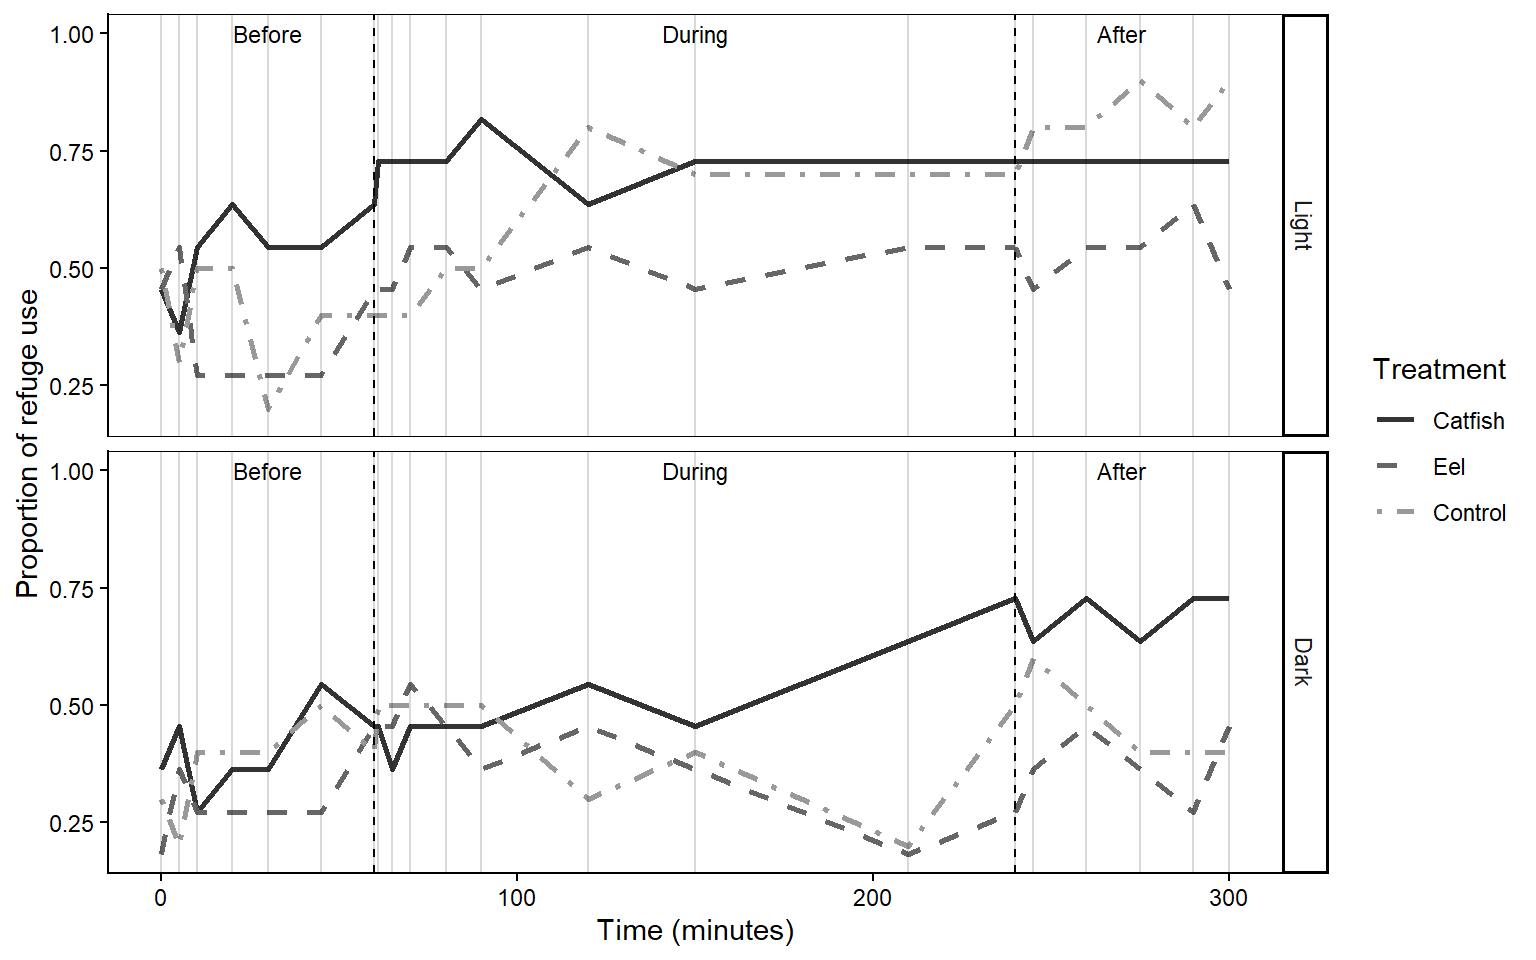

In [ ]:

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
         location  = factor(location,  levels = c("refuge","open")),
         light     = factor(light,     levels = c("light", "dark")))

refuge_plot <- prop_location_time %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  annotate("text", x = 30,  y = 1, label = "Before", size = 3) +
  annotate("text", x = 150, y = 1, label = "During", size = 3) +
  annotate("text", x = 270, y = 1, label = "After",  size = 3) +
  scale_colour_manual(values = c("catfish" = "grey20",  "eel"  = "grey40",  "control" = "grey60"),
                      labels = c("catfish" = "Catfish", "eel" = "Eel", "control" = "Control")) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash"),
                        labels = c("catfish" = "Catfish", "eel" = "Eel", "control" = "Control")) +
  facet_grid(light ~ ., scales = "free_x", labeller = as_labeller(str_to_title)) +
  labs(x = "Time (minutes)", y = "Proportion of refuge use", colour = "Treatment", linetype = "Treatment")

ggsave(file.path(out_dir, "fig-refuge-plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)


## Refuge stats

 Family: betabinomial  ( logit )
Formula:          
cbind(n_refuge, n_total - n_refuge) ~ treatment + period + (1 |  
    tank) + (1 | round)
Data: light_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    327.4     347.9    -155.7     311.4        88 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 tank   (Intercept) 0.4338   0.6586  
 round  (Intercept) 0.1838   0.4287  
Number of obs: 96, groups:  tank, 8; round, 4

Dispersion parameter for betabinomial family (): 0.62 

Conditional model:
                 Estimate Std. Error z value Pr(>|z|)   
(Intercept)      -0.06467    0.50077  -0.129  0.89724   
treatmentcatfish  0.14791    0.45916   0.322  0.74736   
treatmenteel     -0.49555    0.44714  -1.108  0.26775   
periodduring      0.76922    0.41903   1.836  0.06640 . 
periodafter       1.21399    0.45441   2.672  0.00755 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 Family: betabinomial  ( logit )
Formula:          
cbind(n_refuge, n_total - n_refuge) ~ treatment + period + (1 |  
    tank) + (1 | round)
Data: dark_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    363.4     383.9    -173.7     347.4        88 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 tank   (Intercept) 0.4547   0.6743  
 round  (Intercept) 0.0379   0.1947  
Number of obs: 96, groups:  tank, 8; round, 4

Dispersion parameter for betabinomial family (): 0.949 

Conditional model:
                 Estimate Std. Error z value Pr(>|z|)  
(Intercept)       -0.7702     0.4620  -1.667   0.0955 .
treatmentcatfish   0.9342     0.4380   2.133   0.0330 *
treatmenteel      -0.4330     0.4248  -1.019   0.3081  
periodduring       0.3174     0.3931   0.807   0.4195  
periodafter        0.6414     0.4087   1.569   0.1166  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

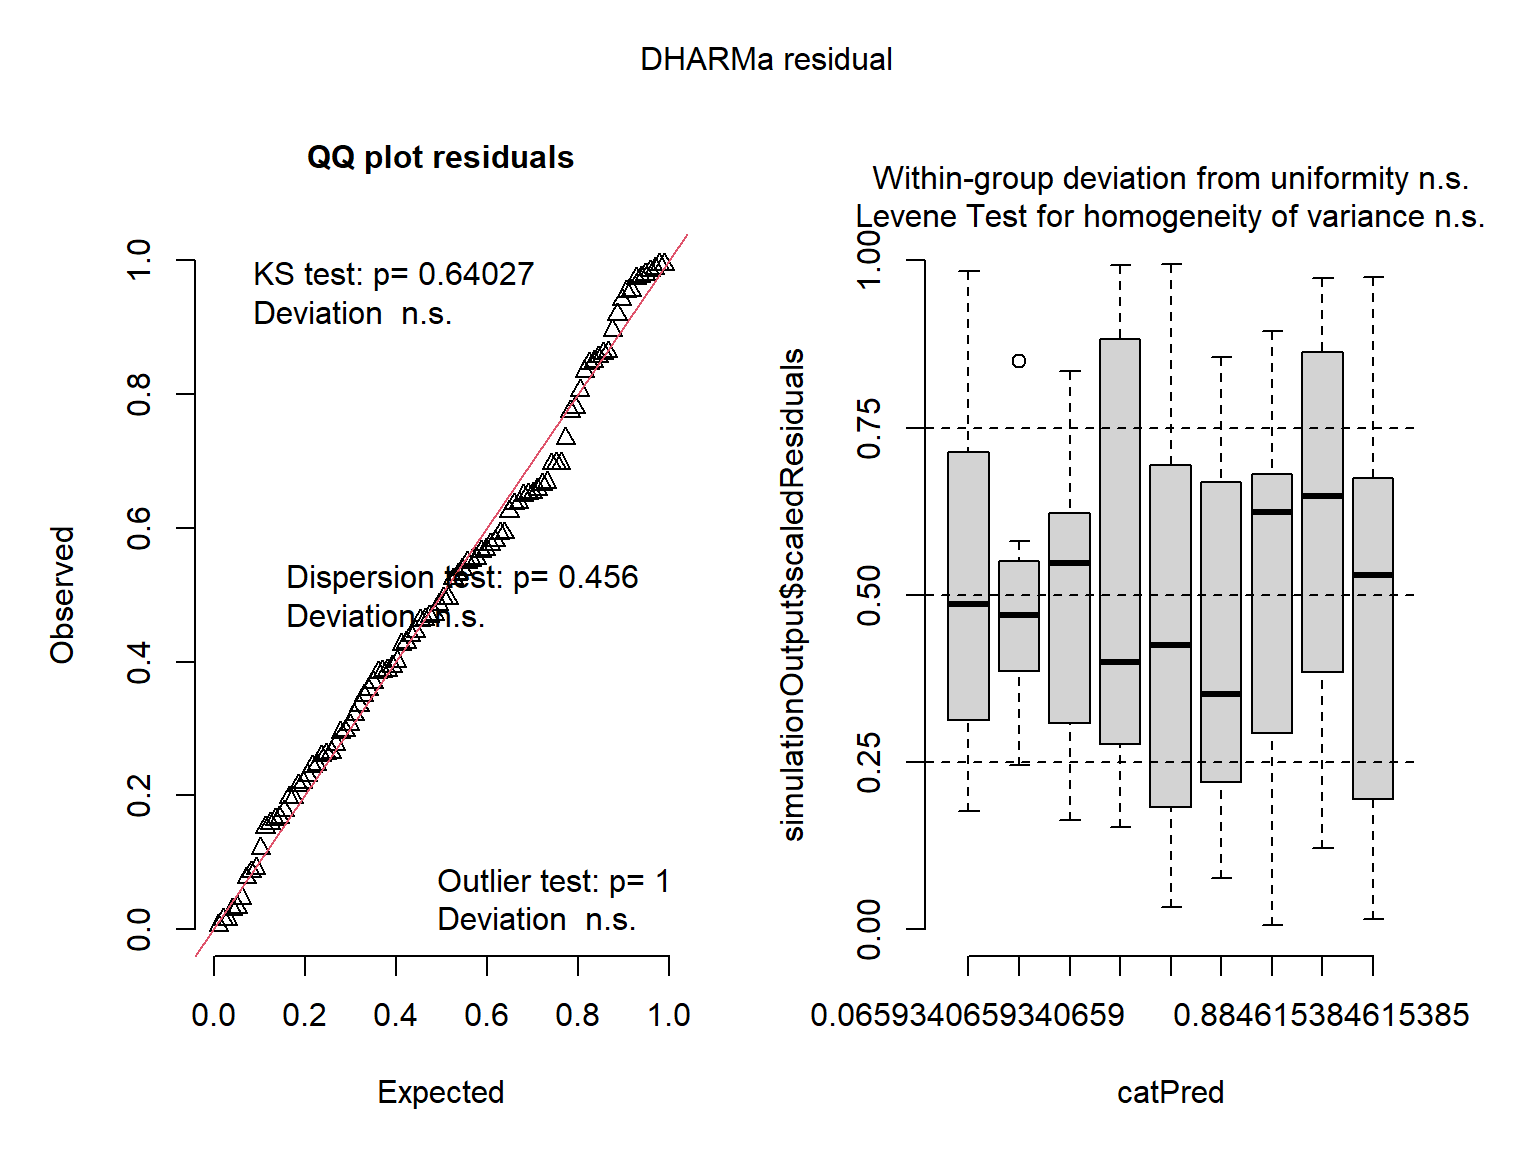

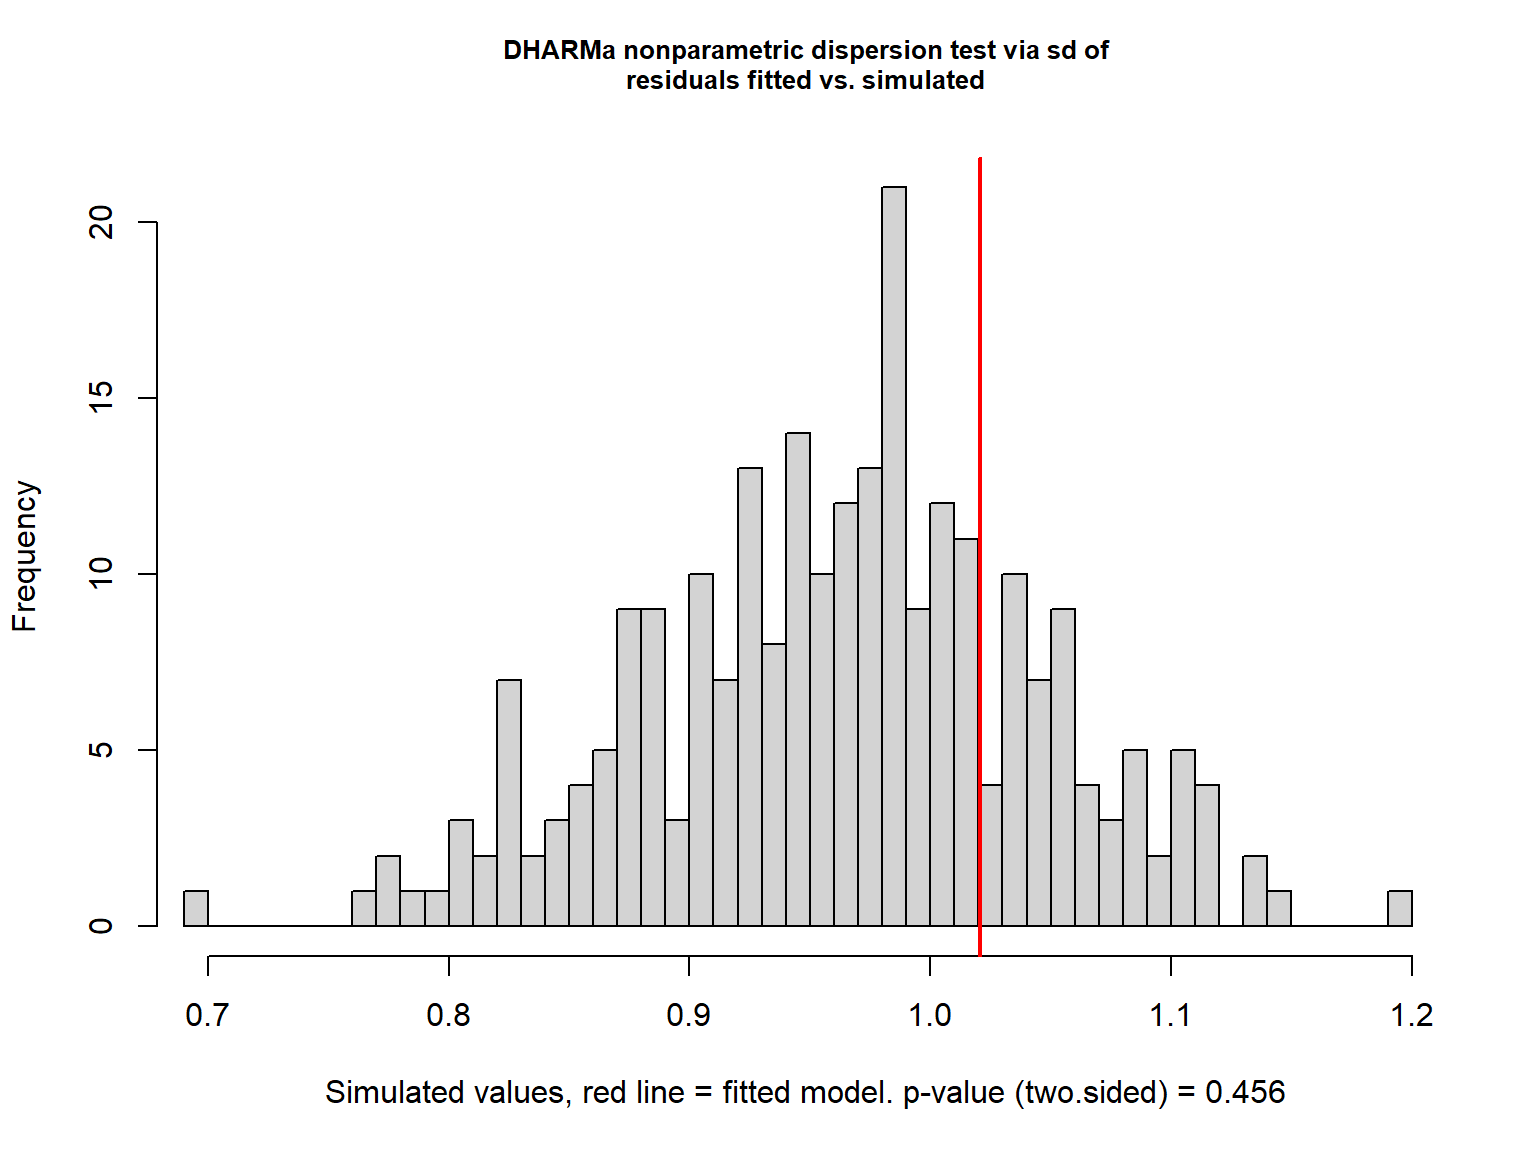


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 1.0596, p-value = 0.456
alternative hypothesis: two.sided

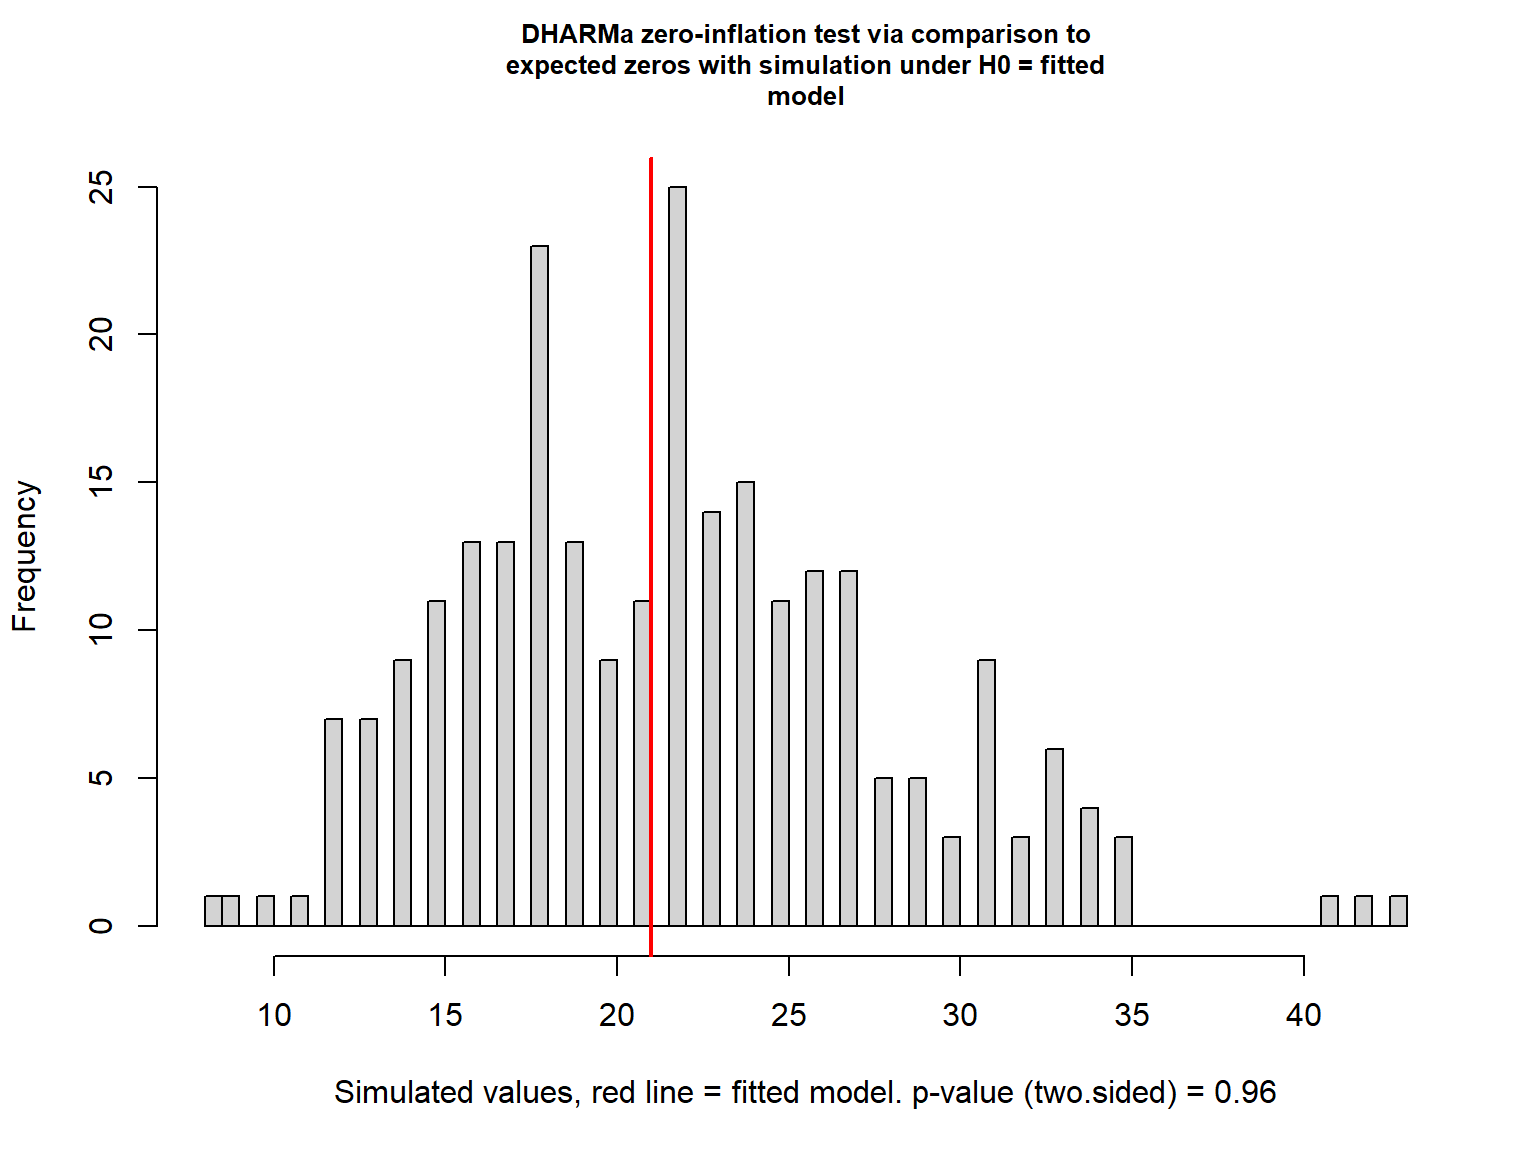


    DHARMa zero-inflation test via comparison to expected zeros with
    simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.96101, p-value = 0.96
alternative hypothesis: two.sided

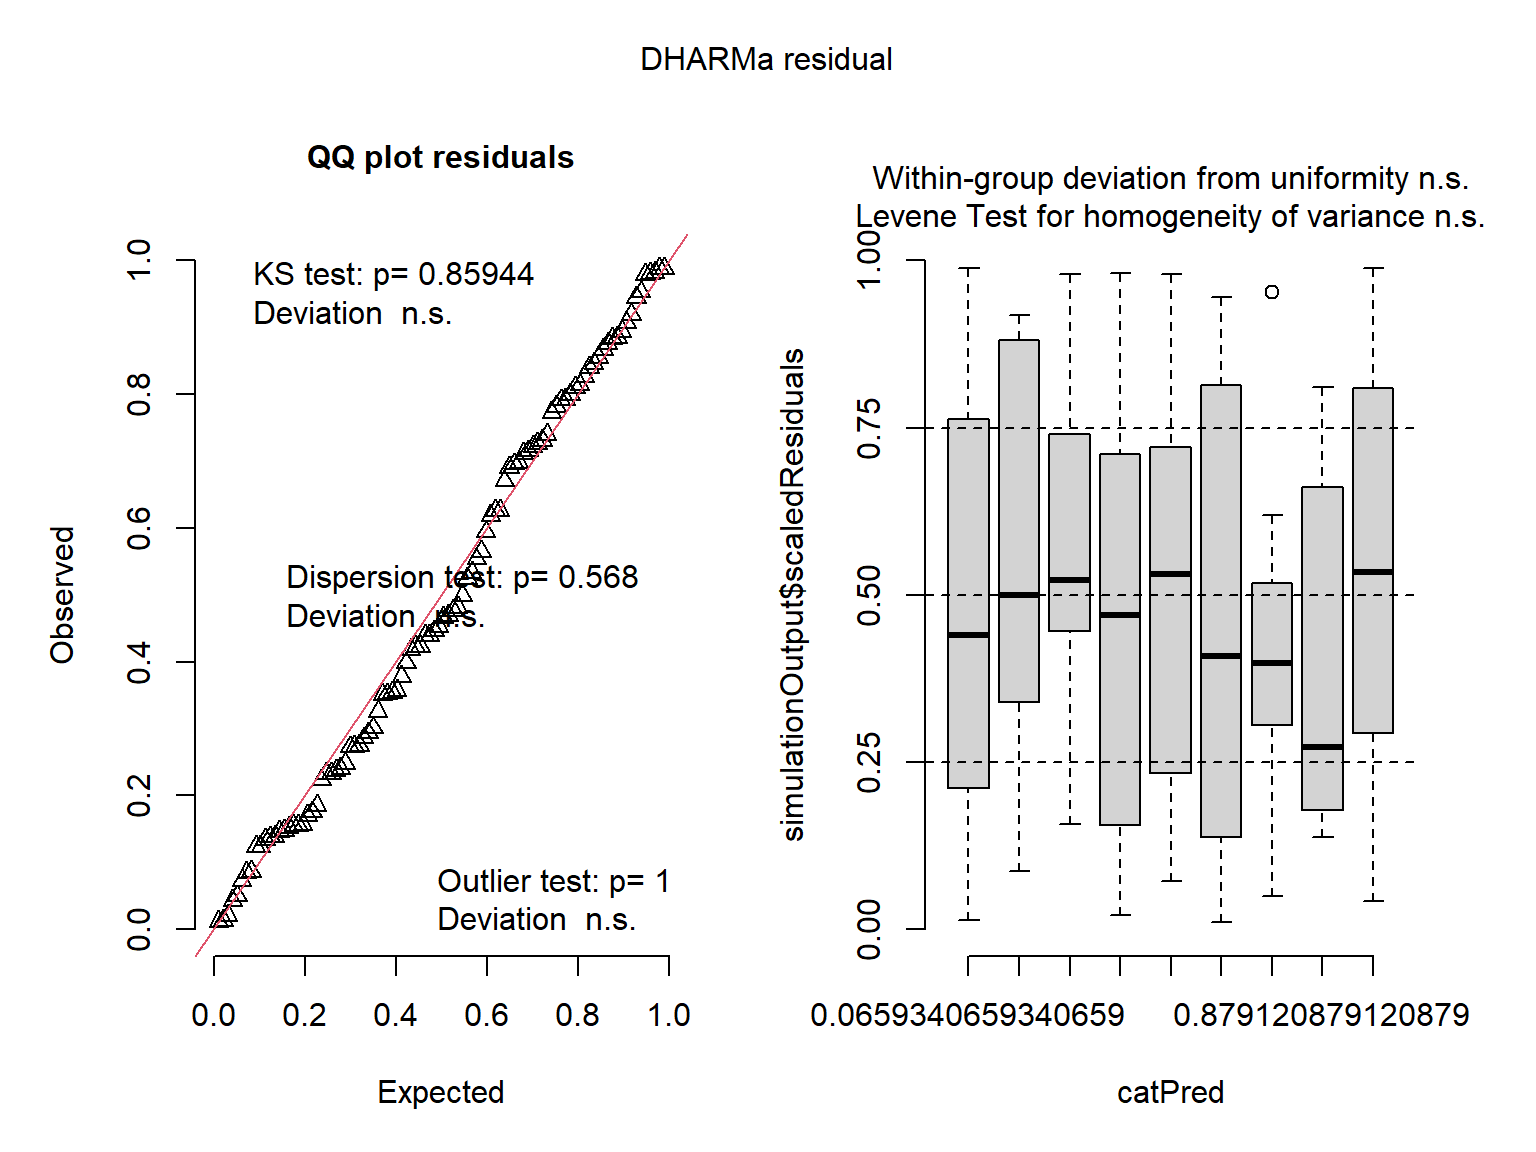

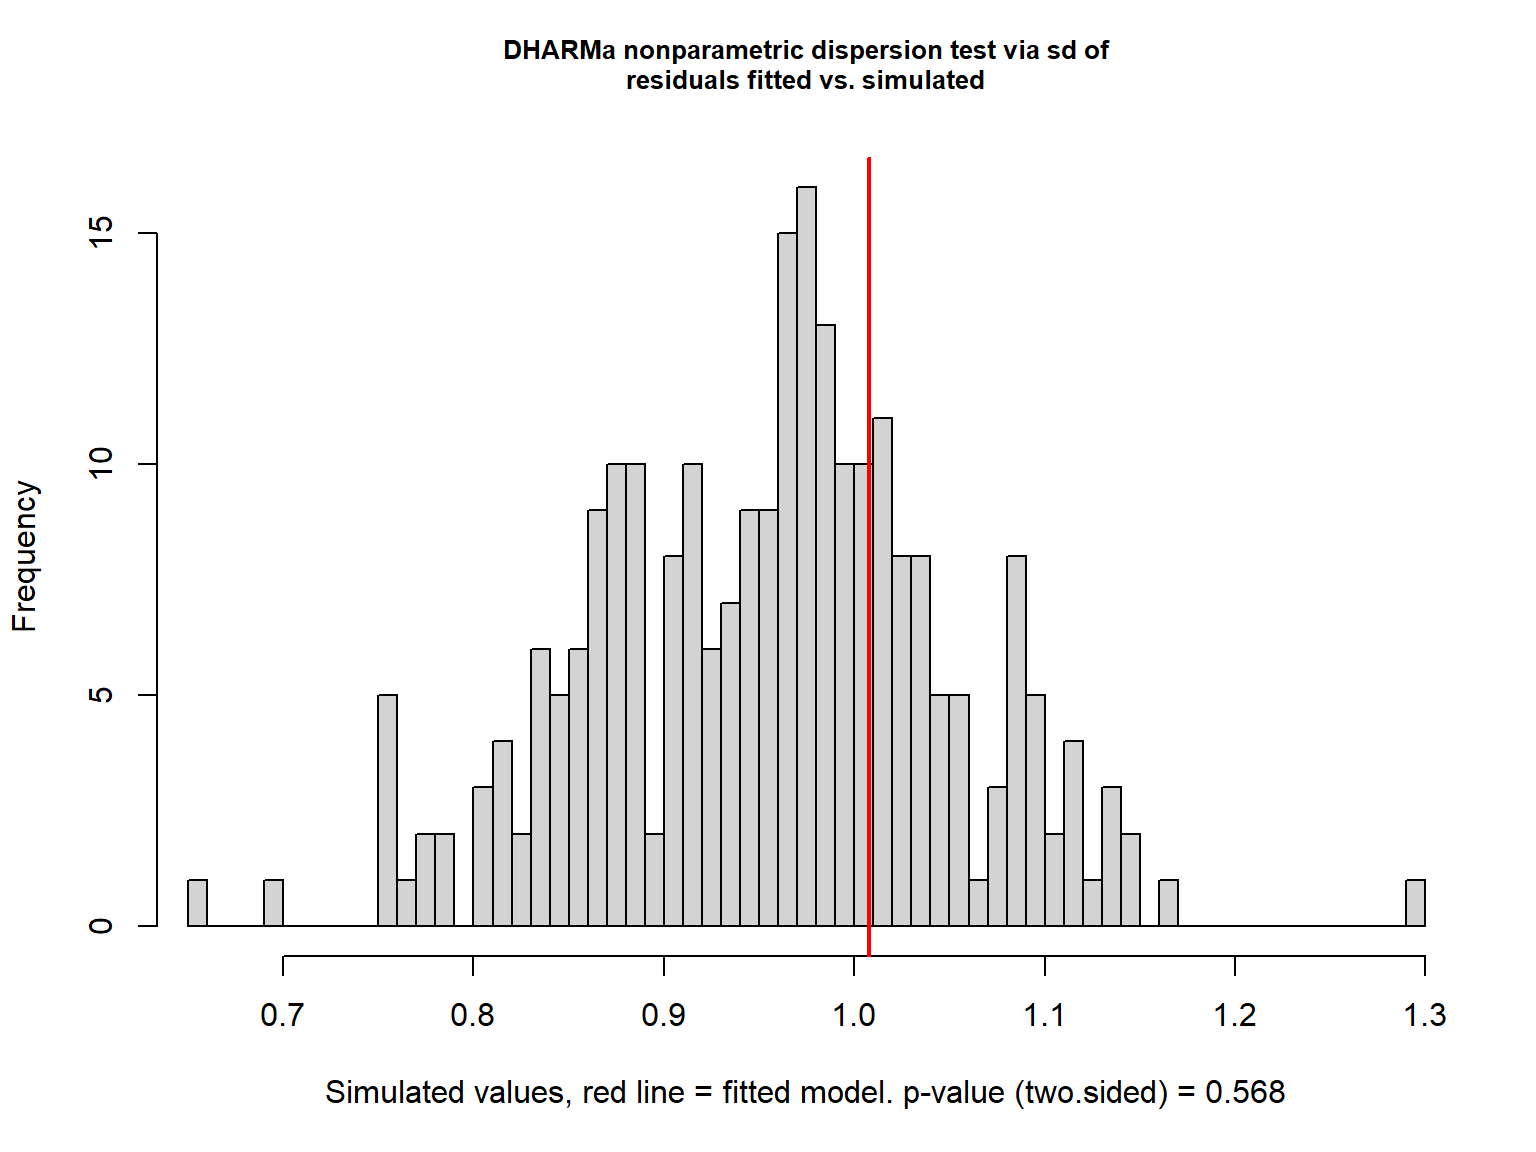


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 1.055, p-value = 0.568
alternative hypothesis: two.sided

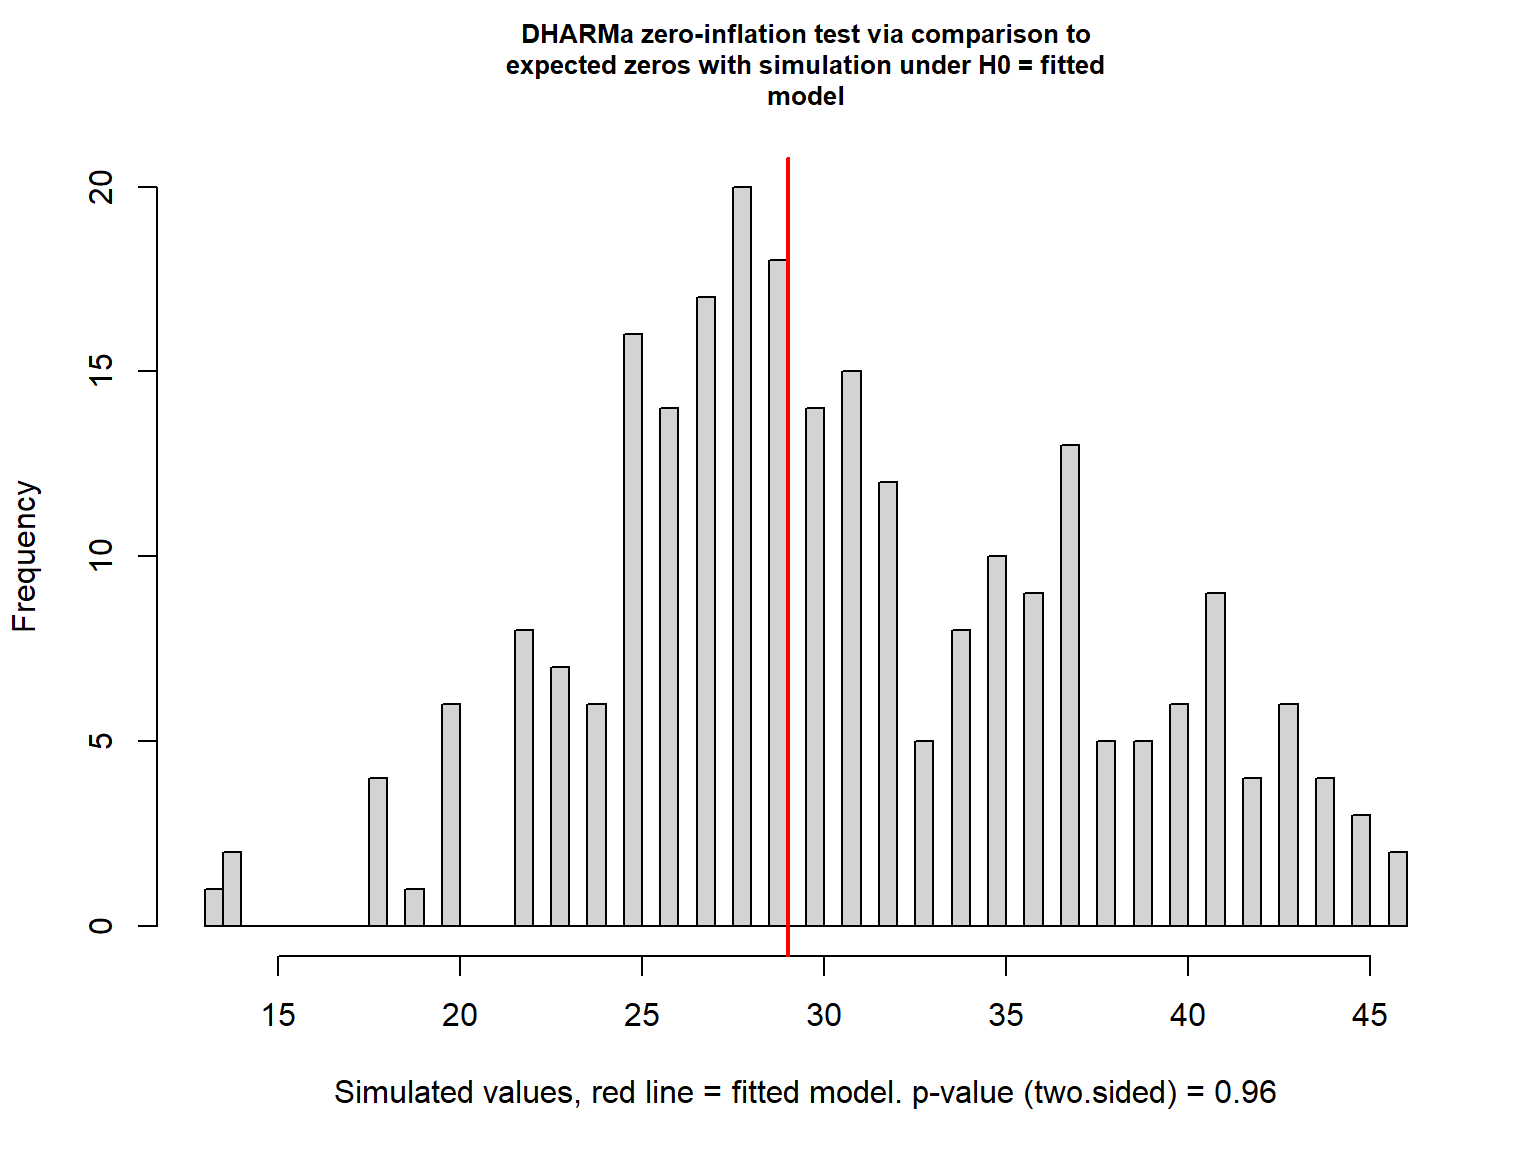


    DHARMa zero-inflation test via comparison to expected zeros with
    simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 0.93888, p-value = 0.96
alternative hypothesis: two.sided

 Family: betabinomial  ( logit )
Formula:          
cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period +  
    (1 | tank)
Data: round_summary

      AIC       BIC    logLik -2*log(L)  df.resid 
    689.1     715.2    -336.6     673.1       184 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 tank   (Intercept) 0.07149  0.2674  
Number of obs: 192, groups:  tank, 8

Dispersion parameter for betabinomial family (): 0.652 

Conditional model:
                 Estimate Std. Error z value Pr(>|z|)   
(Intercept)      -0.06839    0.29985  -0.228  0.81959   
treatmentcatfish  0.46934    0.30010   1.564  0.11783   
treatmenteel     -0.41649    0.29806  -1.397  0.16232   
lightdark        -0.66760    0.23981  -2.784  0.00537 **
periodduring      0.52791    0.28217   1.871  0.06136 . 
periodafter       0.90619    0.30082   3.012  0.00259 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [ ]:

koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id, size_mm1, weight_g1) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id, size_mm1, weight_g1) %>%
  summarise(n_total  = n(),n_refuge = sum(location == "refuge"), .groups  = "drop") %>%
  mutate(treatment = relevel(factor(treatment), ref = "control"),
    light = relevel(factor(light), ref = "light"),   
    period = relevel(factor(period), ref = "before"))

# Light condition only (rounds 1-4)
light_data <- round_summary %>% filter(light == "light")
m_light <- glmmTMB(cbind(n_refuge, n_total - n_refuge) ~ treatment + period + (1|tank) + (1|round), 
                    data = light_data, family = betabinomial)

# Dark condition only (rounds 5-8)
dark_data <- round_summary %>% filter(light == "dark")
m_dark <- glmmTMB(cbind(n_refuge, n_total - n_refuge) ~ treatment + period + (1|tank) + (1|round), 
                   data = dark_data, family = betabinomial)

summary(m_light)


## Fixed effects - Light and Dark

In [ ]:

# Light condition
fixed_light <- as.data.frame(summary(m_light)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(condition = "Light", across(where(is.numeric), round, 3))


ℹ In argument: `across(where(is.numeric), round, 3)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))

  Condition   Term                 Estimate   Std. Error   z value   p value
  ----------- ------------------ ---------- ------------ --------- ---------
  Light       (Intercept)            -0.065        0.501    -0.129     0.897
  Light       treatmentcatfish        0.148        0.459     0.322     0.747
  Light       treatmenteel           -0.496        0.447    -1.108     0.268
  Light       periodduring            0.769        0.419     1.836     0.066
  Light       periodafter             1.214        0.454     2.672     0.008
  Dark        (Intercept)            -0.770        0.462    -1.667     0.095
  Dark        treatmentcatfish        0.934        0.438     2.133     0.033
  Dark        treatmenteel           -0.433        0.425    -1.019     0.308
  Dark        periodduring            0.317        0.393     0.807     0.419
  Dark        periodafter             0.641        0.409     1.569     0.117


## Emmeans - Light and Dark

In [ ]:

# Light
emm_treat_light <- pairs(emmeans(m_light, ~ treatment, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Light")

emm_period_light <- pairs(emmeans(m_light, ~ period, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Light")

# Dark
emm_treat_dark <- pairs(emmeans(m_dark, ~ treatment, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Dark")

emm_period_dark <- pairs(emmeans(m_dark, ~ period, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Dark")

# Combine
emmeans_stratified <- bind_rows(emm_treat_light, emm_period_light, emm_treat_dark, emm_period_dark) %>%
  select(condition, everything()) %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(emmeans_stratified, file.path(out_dir, "tbl-emmeans-stratified.csv"), row.names = FALSE)

knitr::kable(emmeans_stratified, col.names = c("Condition", "Contrast", "Odds ratio", "SE", "df", "Null", "z value", "p value"))


  ---------------------------------------------------------------------------------
  Condition   Contrast            Odds ratio      SE    df   Null  z value  p value
  ----------- ------------------ ----------- ------- ----- ------ -------- --------
  Light       control / catfish        0.863   0.396   Inf      1   -0.322    0.944

  Light       control / eel            1.641   0.734   Inf      1    1.108    0.509

  Light       catfish / eel            1.903   0.866   Inf      1    1.414    0.333

  Light       before / during          0.463   0.194   Inf      1   -1.836    0.158

  Light       before / after           0.297   0.135   Inf      1   -2.672    0.021

  Light       during / after           0.641   0.294   Inf      1   -0.969    0.597

  Dark        control / catfish        0.393   0.172   Inf      1   -2.133    0.083

  Dark        control / eel            1.542   0.655   Inf      1    1.019    0.565

  Dark        catfish / eel            3.924   1.693   Inf      1    3.170    0.004

  Dark        before / during          0.728   0.286   Inf      1   -0.807    0.698

  Dark        before / after           0.527   0.215   Inf      1   -1.569    0.259

  Dark        during / after           0.723   0.290   Inf      1   -0.809    0.698
  ---------------------------------------------------------------------------------


## Emmeans plots - Light and Dark

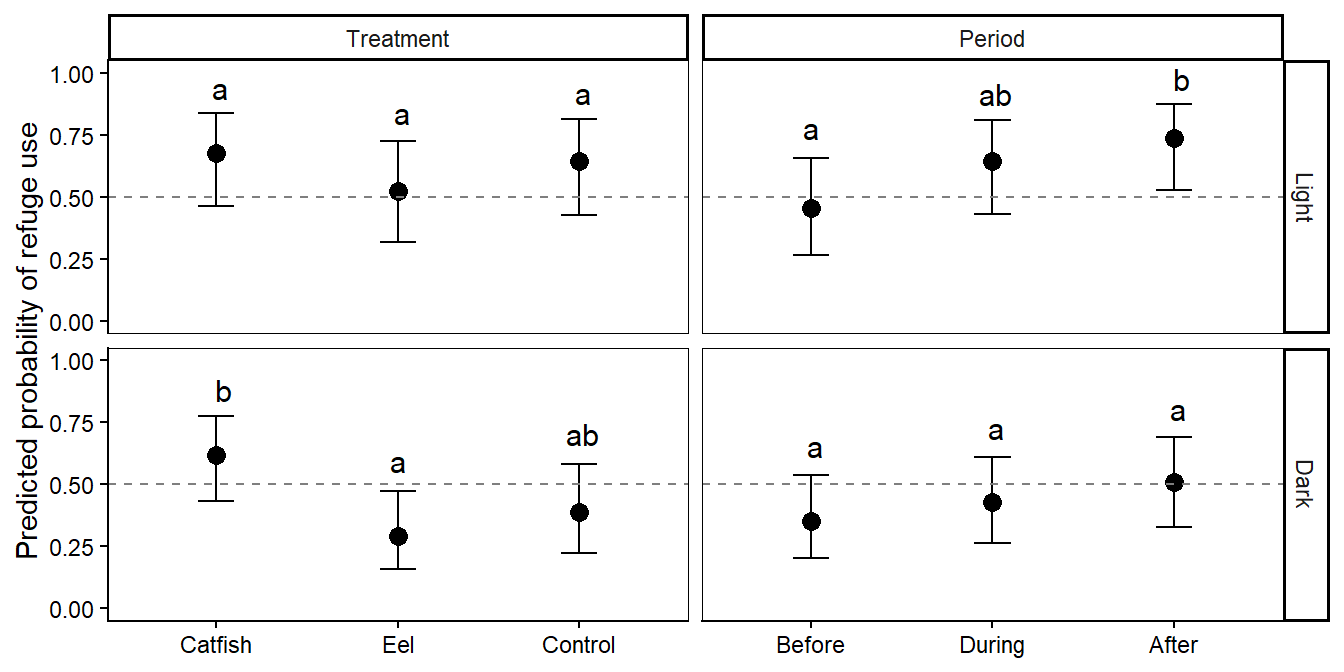

In [ ]:

# Get predictions AND compute CLDs for both models
# Light condition
emm_treat_light_pred <- as.data.frame(emmeans(m_light, ~ treatment, type = "response")) %>%
  mutate(condition = "Light", factor = "Treatment", x = str_to_title(treatment))
cld_treat_light <- as.data.frame(multcomp::cld(emmeans(m_light, ~ treatment, type = "response"), 
                                                Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Light", factor = "Treatment", x = str_to_title(treatment))

emm_period_light_pred <- as.data.frame(emmeans(m_light, ~ period, type = "response")) %>%
  mutate(condition = "Light", factor = "Period", x = str_to_title(period))
cld_period_light <- as.data.frame(multcomp::cld(emmeans(m_light, ~ period, type = "response"), 
                                                 Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Light", factor = "Period", x = str_to_title(period))

# Dark condition
emm_treat_dark_pred <- as.data.frame(emmeans(m_dark, ~ treatment, type = "response")) %>%
  mutate(condition = "Dark", factor = "Treatment", x = str_to_title(treatment))
cld_treat_dark <- as.data.frame(multcomp::cld(emmeans(m_dark, ~ treatment, type = "response"), 
                                               Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Dark", factor = "Treatment", x = str_to_title(treatment))

emm_period_dark_pred <- as.data.frame(emmeans(m_dark, ~ period, type = "response")) %>%
  mutate(condition = "Dark", factor = "Period", x = str_to_title(period))
cld_period_dark <- as.data.frame(multcomp::cld(emmeans(m_dark, ~ period, type = "response"), 
                                                Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Dark", factor = "Period", x = str_to_title(period))

# Combine all (Period first, Treatment second for left-to-right order)
emm_all_stratified <- bind_rows(emm_period_light_pred, emm_treat_light_pred,
                                emm_period_dark_pred, emm_treat_dark_pred) %>%
  mutate(condition = factor(condition, levels = c("Light","Dark")),
  factor = factor(factor, levels = c("Treatment", "Period")),
  x = factor(x, levels = c("Catfish", "Eel", "Control", "Before", "During", "After")))


cld_all_stratified <- bind_rows(cld_period_light, cld_treat_light,
                                cld_period_dark, cld_treat_dark) %>%
  mutate(condition = factor(condition, levels = c("Light","Dark")),
  factor = factor(factor, levels = c("Treatment", "Period")),
  x = factor(x, levels = c("Catfish", "Eel", "Control", "Before", "During", "After")))


# Plot with letters
emmeans_plot_stratified <- ggplot(emm_all_stratified, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_all_stratified, aes(x = x, y = asymp.UCL + 0.08, label = .group), inherit.aes = FALSE, size = 4) +
  facet_grid(condition ~ factor, scales = "free_x") +
  scale_y_continuous("Predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50") 

ggsave(file.path(out_dir, "fig-emmeans-stratified.png"), emmeans_plot_stratified, width = 5, height = 4, dpi = 300)

emmeans_plot_stratified


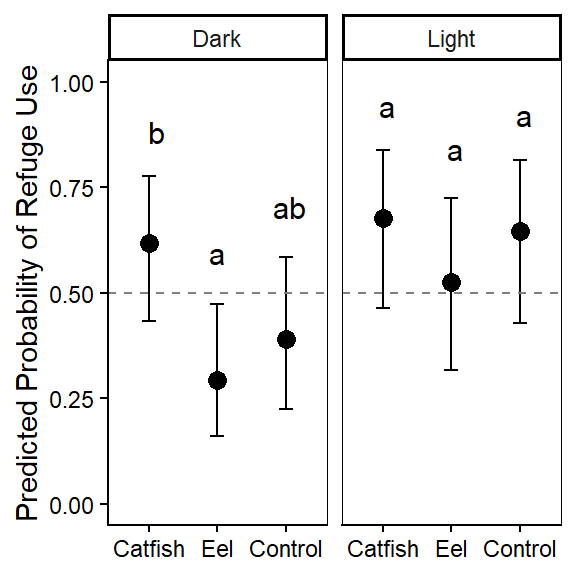

In [ ]:

emm_treat_light_pred <- as.data.frame(emmeans(m_light, ~ treatment, type = "response")) %>%
  mutate(condition = "Light", x = str_to_title(treatment))
cld_treat_light <- as.data.frame(multcomp::cld(emmeans(m_light, ~ treatment, type = "response"), 
                                                Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Light", x = str_to_title(treatment))

emm_treat_dark_pred <- as.data.frame(emmeans(m_dark, ~ treatment, type = "response")) %>%
  mutate(condition = "Dark", x = str_to_title(treatment))
cld_treat_dark <- as.data.frame(multcomp::cld(emmeans(m_dark, ~ treatment, type = "response"), 
                                               Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Dark", x = str_to_title(treatment))

emm_treat_all <- bind_rows(emm_treat_light_pred, emm_treat_dark_pred) %>%
  mutate(condition = factor(condition, levels = c("Dark", "Light")),
         x = factor(x, levels = c("Catfish", "Eel", "Control")))

cld_treat_all <- bind_rows(cld_treat_light, cld_treat_dark) %>%
  mutate(condition = factor(condition, levels = c("Dark", "Light")),
         x = factor(x, levels = c("Catfish", "Eel", "Control")))

treat_plot <- ggplot(emm_treat_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_treat_all, aes(x = x, y = asymp.UCL + 0.08, label = .group), 
            inherit.aes = FALSE, size = 4) +
  facet_wrap(~ condition) +
  scale_y_continuous("Predicted Probability of Refuge Use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "fig-treatment-emmeans.png"), treat_plot, width = 4, height = 3, dpi = 300)

treat_plot


## Summary table of koura used

In [ ]:

grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2)


  ------------------------------------------------------------------------------------------------------------------------------------------------
  grouping          treatment   light     n_trials   mean_size   sd_size   min_size   max_size   mean_weight   sd_weight   min_weight   max_weight
  ----------------- ----------- ------- ---------- ----------- --------- ---------- ---------- ------------- ----------- ------------ ------------
  treatment+light   catfish     dark            11       25.99      2.97      21.46      30.28         11.64        4.06            6           19

  treatment+light   catfish     light           11       26.45      1.53      23.84      28.47         11.45        2.91            8           17

  treatment+light   control     dark            10       25.93      4.76      18.35      32.95         11.60        6.79            3           23

  treatment+light   control     light           10       26.17      1.86      23.71      29.97         11.50        2.88            9           17

  treatment+light   eel         dark            11       25.16      4.37      18.35      30.95         12.00        5.62            3           21

  treatment+light   eel         light           11       26.66      2.12      23.58      29.49         12.00        2.86            8           17

  treatment         catfish     All             22       26.22      2.32      21.46      30.28         11.55        3.45            6           19

  treatment         control     All             20       26.05      3.52      18.35      32.95         11.55        5.07            3           23

  treatment         eel         All             22       25.91      3.44      18.35      30.95         12.00        4.35            3           21

  light             All         dark            32       25.68      3.97      18.35      32.95         11.75        5.38            3           23

  light             All         light           32       26.44      1.81      23.58      29.97         11.66        2.80            8           17

  overall           All         All             64       26.06      3.08      18.35      32.95         11.70        4.25            3           23
  ------------------------------------------------------------------------------------------------------------------------------------------------


## Plots individual koura

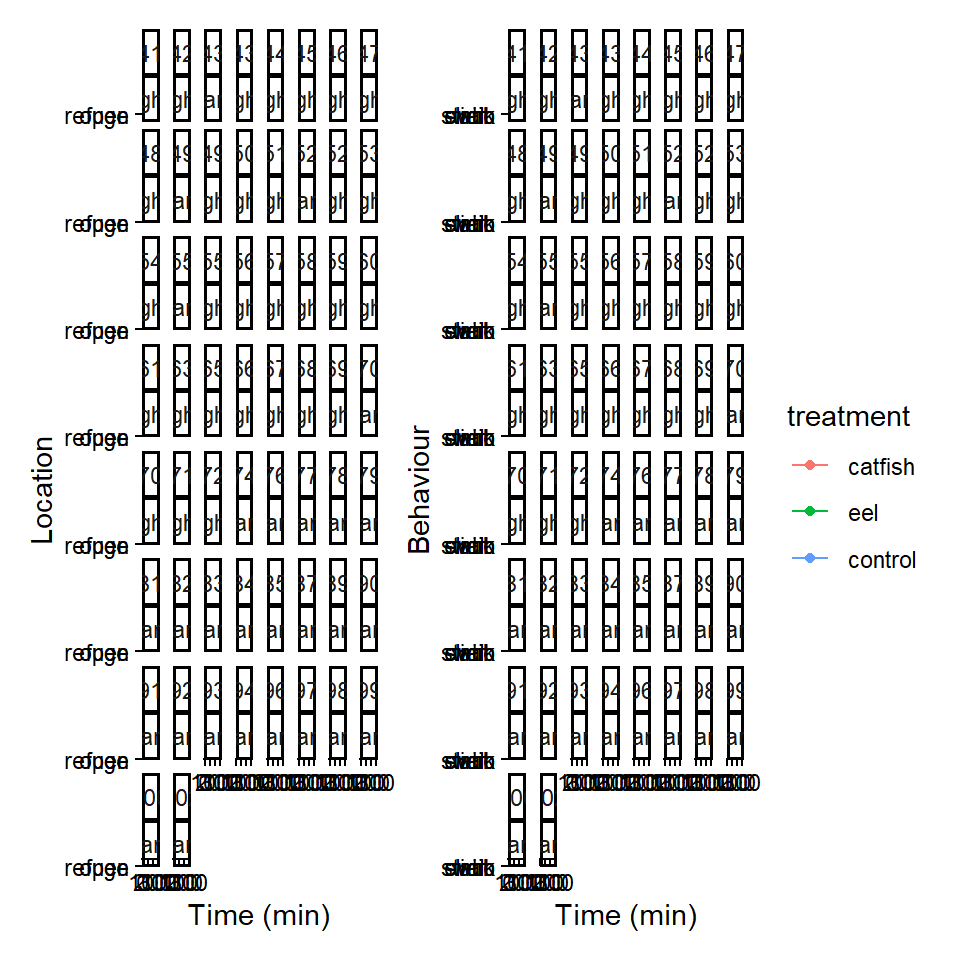

In [ ]:

loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))


koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = koura_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "Time (min)", y = "Location")+
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_behaviour_time, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = koura_id))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "Time (min)", y = "Behaviour")

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot


## Koura length refuge use

# A tibble: 64 × 6
   exp_id treatment size_mm1 total_obs refuge_obs prop_refuge
    <int> <chr>        <dbl>     <int>      <int>       <dbl>
 1      1 catfish       27.2        21         20      0.952 
 2      2 eel           26.0        21         15      0.714 
 3      3 control       23.7        21          9      0.429 
 4      4 catfish       24.7        21         21      1     
 5      5 eel           29.5        21          1      0.0476
 6      6 control       24.6        21          8      0.381 
 7      7 catfish       23.8        21         20      0.952 
 8      8 eel           24.2        21         21      1     
 9      9 control       25.8        21          9      0.429 
10     10 catfish       28.5        21         14      0.667 
# ℹ 54 more rows

Warning in cor.test.default(cor_catfish$size_mm1, cor_catfish$prop_refuge, :
Cannot compute exact p-value with ties

Warning in cor.test.default(cor_eel$size_mm1, cor_eel$prop_refuge, method =
"spearman"): Cannot compute exact p-value with ties

Warning in cor.test.default(cor_control$size_mm1, cor_control$prop_refuge, :
Cannot compute exact p-value with ties


    Spearman's rank correlation rho

data:  cor_catfish$size_mm1 and cor_catfish$prop_refuge
S = 1929.1, p-value = 0.6927
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.08928623 


    Spearman's rank correlation rho

data:  cor_eel$size_mm1 and cor_eel$prop_refuge
S = 1606, p-value = 0.6801
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
0.09315701 


    Spearman's rank correlation rho

data:  cor_control$size_mm1 and cor_control$prop_refuge
S = 1113.9, p-value = 0.4936
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.1625111 

[1] 1 1 1

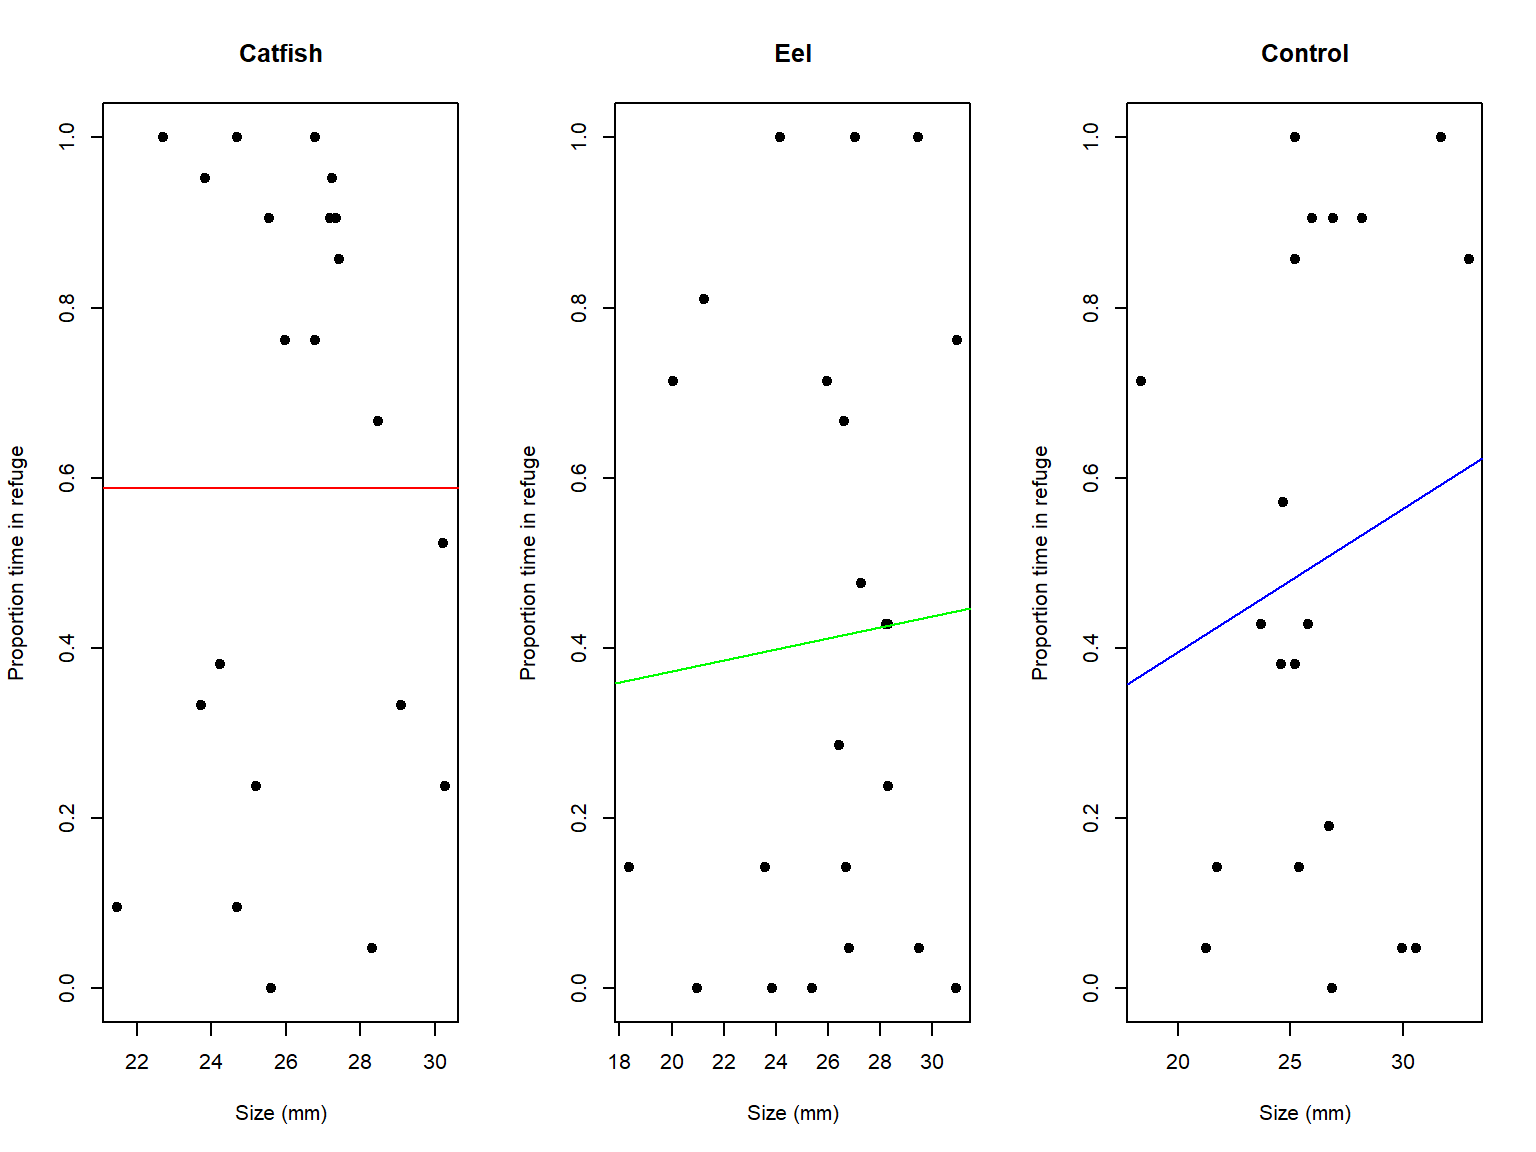

In [ ]:

# Calculate proportion of time each koura spent in refuge (overall)
refuge_by_koura <- koura_long_ref %>%
  group_by(exp_id , treatment, size_mm1) %>%
  summarise(
    total_obs = n(),
    refuge_obs = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = refuge_obs / total_obs,
    .groups = "drop"
  )

# Check what you have
print(refuge_by_koura)


## Koura before behaviour

In [ ]:

df_before <- koura_long_ref %>% 
  filter(period =="before") %>%
  filter(!is.na(location), location != "") %>%
  count(exp_id, treatment, light, location = location, name = "n") %>%
  group_by(exp_id) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = c("refuge","open"))) %>%
  filter(location == "refuge")

# Coefficient of Variation (CV)
before_cv_ref <- df_before %>%
  group_by(light) %>%
  summarise(cv = sd(prop) / mean(prop) * 100)

#leveneTest(prop ~ light, data = df_before)
#fligner.test(prop ~ light, data = df_before)


time_compare <- koura_long_ref %>%
  filter(time == 5 | time == 60) %>%
  filter(!is.na(location), location != "") %>%
  group_by(time, location) %>%
  summarise(n = n(), .groups = "drop") %>%
  pivot_wider(names_from = location, values_from = n, values_fill = 0)

# contingency table
cont_table <- time_compare %>%
  select(refuge, open) %>%
  as.matrix()

rownames(cont_table) <- c("time_5", "time_60")


# Feeding experiment

## Feeding table

In [ ]:

df_feeding <- df_Feeding_raw %>%
  filter(sex != "F") %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve),
    treatment = factor(treatment, levels = c("catfish", "eel", "control")))


# summary table
feeding_summary <- df_feeding %>%
  group_by(treatment, day_starve) %>%
  summarise(
    mean = round(mean(pellets_per_g, na.rm = TRUE), 3),
    se   = round(sd(pellets_per_g, na.rm = TRUE) / sqrt(n()), 3),
    .groups = "drop"
  )

# helper for inline use
get_mean_se <- function(trt, starve) {
  row <- feeding_summary %>% filter(treatment == trt, day_starve == starve)
  paste0(row$mean, " ± ", row$se)
}

knitr::kable(feeding_summary, col.names = c("Treatment", "Days starved", "Mean (pellets/g)", "SE"))


  Treatment   Days starved     Mean (pellets/g)      SE
  ----------- -------------- ------------------ -------
  catfish     0                           0.027   0.018
  catfish     3                           0.235   0.055
  catfish     4                           0.059   0.017
  eel         0                           0.039   0.028
  eel         3                           0.105   0.037
  eel         4                           0.052   0.028
  control     0                           0.000   0.000
  control     3                           0.134   0.046
  control     4                           0.148   0.050


## Feeding plot

Warning in stat_summary(fun = mean, geom = "bar", position = position_dodge(0.9), : Ignoring unknown parameters: `pattern_fill`, `pattern_colour`,
`pattern_density`, and `pattern_spacing`

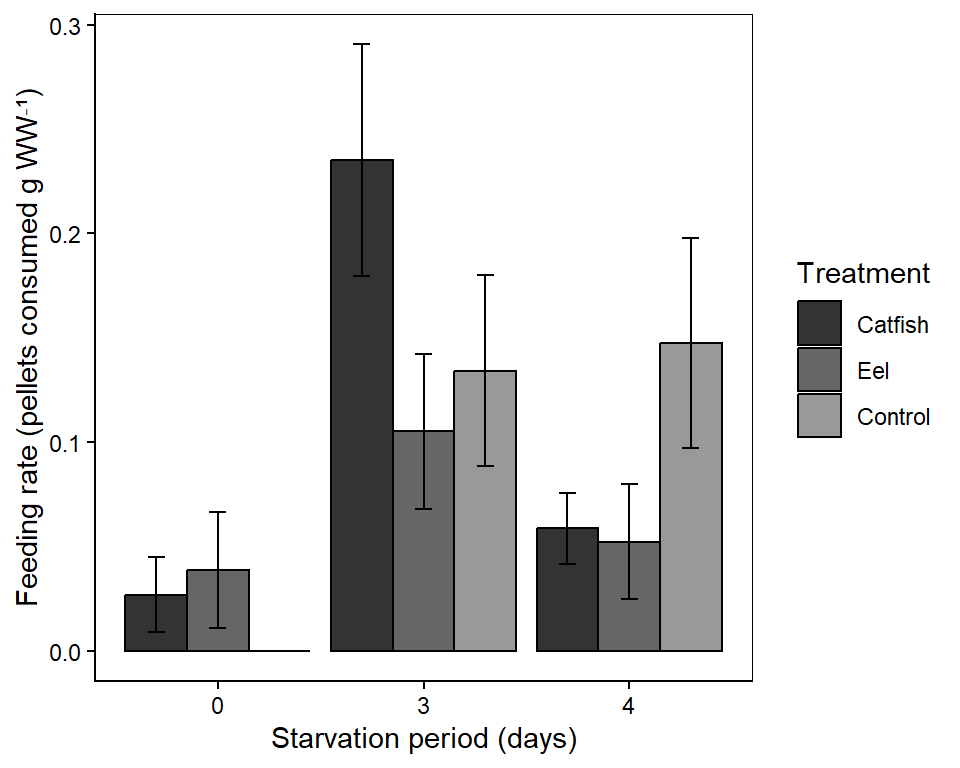

In [ ]:

feeding_plot <- ggplot(df_feeding, aes(x = factor(day_starve),  y = pellets_per_g, fill = treatment)) +
  stat_summary(fun = mean, geom = "bar", position = position_dodge(0.9), colour = "black", linewidth = 0.4, pattern_fill = "black",pattern_colour = "black", pattern_density = 0.3, pattern_spacing = 0.05) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.25, linewidth = 0.5,  position = position_dodge(0.9)) +
  scale_fill_manual(values = c("catfish" = "gray20",  "eel"  = "grey40",  "control" = "grey60"),
                   labels = c("catfish" = "Catfish", "eel" = "Eel", "control" = "Control")) +
  labs(x = "Starvation period (days)",  y = "Feeding rate (pellets consumed g WW⁻¹)",  fill = "Treatment") +
  theme(legend.position = "right")


## Feeding stats

boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')

   model       AIC       BIC   logLik      AICc  k delta_AICc
m0    m0 -67.26828 -61.78236 36.63414 -66.69686  3       0.00
m6    m6 -67.33289 -58.18969 38.66645 -65.83289  5       0.86
m5    m5 -54.53096 -45.38775 32.26548 -53.03096  5      13.67
m2    m2 -55.26897 -42.46848 34.63449 -52.32160  7      14.38
m1    m1 -42.39323 -22.27817 32.19662 -34.62852 11      32.07

boundary (singular) fit: see help('isSingular')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: pellets_per_g ~ day_starve + (1 | exp_tank)
   Data: df_feeding

REML criterion at convergence: -77.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7300 -0.5306 -0.2542  0.3916  2.7170 

Random effects:
 Groups   Name        Variance Std.Dev.
 exp_tank (Intercept) 0.000000 0.00000 
 Residual             0.008013 0.08952 
Number of obs: 46, groups:  exp_tank, 16

Fixed effects:
            Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)  0.02276    0.02392 43.00000   0.951 0.346803    
day_starve3  0.13211    0.03276 43.00000   4.033 0.000222 ***
day_starve4  0.06736    0.03276 43.00000   2.056 0.045878 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr) dy_st3
day_starve3 -0.730       
day_starve4 -0.730  0.533
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('i

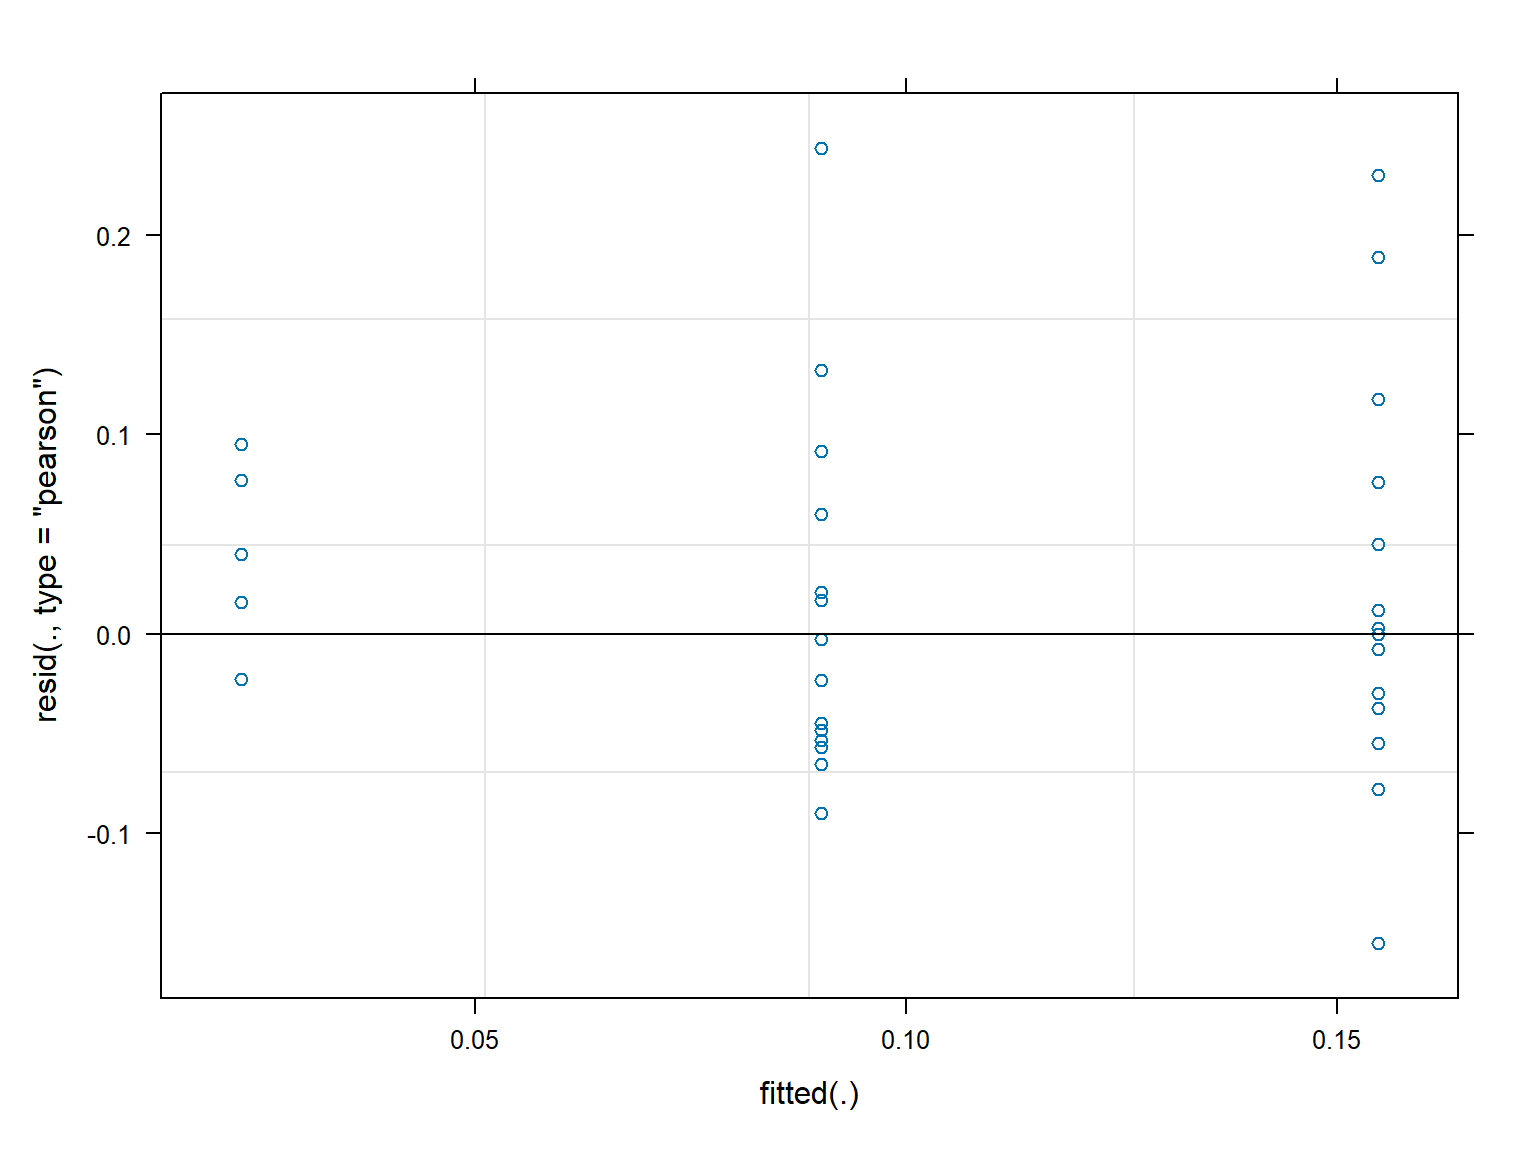


    Shapiro-Wilk normality test

data:  residuals(lmm_feed)
W = 0.92525, p-value = 0.005716

 contrast                  estimate     SE   df t.ratio p.value
 day_starve0 - day_starve3  -0.1321 0.0329 29.5  -4.019  0.0010
 day_starve0 - day_starve4  -0.0674 0.0329 29.5  -2.049  0.1182
 day_starve3 - day_starve4   0.0647 0.0316 28.2   2.046  0.1198

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 3 estimates 


Call:
lm(formula = pellets_per_g ~ treatment, data = df_day0)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.039027 -0.027083 -0.000283  0.000000  0.078620 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)
(Intercept)       0.02708    0.01685   1.608    0.136
treatmenteel      0.01194    0.02664   0.448    0.663
treatmentcontrol -0.02708    0.02664  -1.017    0.331

Residual standard error: 0.04127 on 11 degrees of freedom
Multiple R-squared:  0.1476,    Adjusted R-squared:  -0.00743 
F-statistic: 0.9521 on 2 and 11 DF,  p-value: 0.4156


Call:
lm(formula = pellets_per_g ~ treatment, data = df_day3)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.13509 -0.09232  0.01611  0.06667  0.14953 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       0.23508    0.04716   4.985  0.00025 ***
treatmenteel     -0.12987    0.06386  -2.034  0.06292 .  
treatmentcontrol -0.10087    0.06670  -1.512  0.15437    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1055 on 13 degrees of freedom
Multiple R-squared:  0.2535,    Adjusted R-squared:  0.1387 
F-statistic: 2.207 on 2 and 13 DF,  p-value: 0.1495


Call:
lm(formula = pellets_per_g ~ treatment, data = df_day4)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.14770 -0.04352 -0.01455  0.03869  0.18564 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)
(Intercept)       0.058706   0.038629   1.520    0.153
treatmenteel     -0.006282   0.054630  -0.115    0.910
treatmentcontrol  0.088991   0.052304   1.701    0.113

Residual standard error: 0.08638 on 13 degrees of freedom
Multiple R-squared:  0.2477,    Adjusted R-squared:  0.1319 
F-statistic:  2.14 on 2 and 13 DF,  p-value: 0.1573

...

 contrast          estimate     SE df t.ratio p.value
 catfish - eel      0.00628 0.0546 13   0.115  0.9927
 catfish - control -0.08899 0.0523 13  -1.701  0.2417
 eel - control     -0.09527 0.0523 13  -1.822  0.2013

P value adjustment: tukey method for comparing a family of 3 estimates 


    Shapiro-Wilk normality test

data:  residuals(lm_day0)
W = 0.82764, p-value = 0.0112


    Shapiro-Wilk normality test

data:  residuals(lm_day3)
W = 0.92707, p-value = 0.219


    Shapiro-Wilk normality test

data:  residuals(lm_day4)
W = 0.97557, p-value = 0.9188


    Kruskal-Wallis rank sum test

data:  pellets_per_g by treatment
Kruskal-Wallis chi-squared = 2.3011, df = 2, p-value = 0.3165

In [ ]:

# Model selection on LMER models
feeding_models_lmer <- list(
  m0 = lmer(pellets_per_g ~ 1 + (1 | exp_tank), data = df_feeding),
  m1 = lmer(pellets_per_g ~ treatment * day_starve + (1 | exp_tank), data = df_feeding),
  m2 = lmer(pellets_per_g ~ treatment + day_starve + (1 | exp_tank), data = df_feeding),
  m5 = lmer(pellets_per_g ~ treatment + (1 | exp_tank), data = df_feeding),
  m6 = lmer(pellets_per_g ~ day_starve + (1 | exp_tank), data = df_feeding))


### feeding anova tbl

In [ ]:

# Extract summary table from lmer
summary_lmm <- summary(lmm_feed)
feed_summary <- as.data.frame(summary_lmm$coefficients) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(feed_summary, file.path(out_dir, "tbl-feeding-summary.csv"), row.names = FALSE)

knitr::kable(feed_summary, 
             col.names = c("Term", "Estimate", "Std. Error", "df", "t value", "p value"),
             digits = 3)


  Term            Estimate   Std. Error   df   t value   p value
  ------------- ---------- ------------ ---- --------- ---------
  (Intercept)        0.023        0.024   43     0.951     0.347
  day_starve3        0.132        0.033   43     4.033     0.000
  day_starve4        0.067        0.033   43     2.056     0.046


# Session info

In [ ]:
sessionInfo()


R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] readxl_1.4.5        lubridate_1.9.5     forcats_1.0.1      
 [4] stringr_1.6.0       dplyr_1.2.0         purrr_1.2.1        
 [7] readr_2.2.0         tidyr_1.3.2         tibble_3.3.1       
[10] ggplot2_4.0.2       tidyverse_2.0.0     patchwork_1.3.2    
[13] multcompView_0.1-11 lmerTest_3.2-1      lme4_1.1-38        
[16] Matrix_1.7-4        emmeans_2.0.2       DHARMa_0.4.7       
[19] AICcmodavg_2.3-4    glmmTMB_1.1.14      DT_0.34.0          


```` markdown
---
title: "Analysis Notebook"
description: "Analysis notebook for NCE kōura catfish experiment"
toc: true
toc-depth: 3
number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false

packages <- c("ggpattern","multcomp","DT","glmmTMB","AICcmodavg","DHARMa","emmeans","lme4","lmerTest","multcompView","patchwork","tidyverse","readxl")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

options(repos = c(CRAN = "https://cloud.r-project.org"))
invisible(lapply(packages, quiet_load))

exc_file_dir <- "data/raw/NCE_data.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

# Read sheets from raw xlsx
df_NCE_raw <- readxl::read_excel(exc_file_dir, sheet = "NCE_exp")
df_Feeding_raw <- readxl::read_excel(exc_file_dir, sheet = "Feeding")

# Save as csv to derived/
write.csv(df_NCE_raw,     file.path(der_data_dir, "NCE_exp.csv"),  row.names = FALSE)
write.csv(df_Feeding_raw, file.path(der_data_dir, "Feeding.csv"),  row.names = FALSE)

df_NCE_raw     <- read.csv(file.path(der_data_dir, "NCE_exp.csv"))
df_Feeding_raw <- read.csv(file.path(der_data_dir, "Feeding.csv"))

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "sans", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

# Format of p values in text, including the correct comparison operator and
# the italic "p" label. Set label = FALSE for values chained after a leading
# "*p*" (e.g. "*p* < 0.001, 0.011, 0.004, respectively").
format_pval <- function(p, label = TRUE) {
  out <- if (p < 0.001) "< 0.001" else paste0("= ", format(round(p, 3), nsmall = 3))
  if (label) paste0("*p* ", out) else out
}

# Get treatment contrast
get_treat_contrast <- function(condition, contrast, label = TRUE) {
  row <- emmeans_stratified %>%
    filter(condition == !!condition, contrast == !!contrast)

  if(nrow(row) == 0) {
    return("Contrast not found")
  }

  format_pval(row$`p.value`[1], label = label)
}

# Get period contrast p-value
get_period_contrast <- function(condition, contrast, label = TRUE) {
  row <- emmeans_stratified %>%
    filter(condition == !!condition, contrast == !!contrast)
  format_pval(row$`p.value`, label = label)
}

# Get OCL correlation
get_ocl_corr <- function(treatment) {
  if(treatment == "catfish") {
    rs <- round(spearman_catfish$estimate, 2)
    p <- format_pval(spearman_catfish$p.value)
  } else if(treatment == "eel") {
    rs <- round(spearman_eel$estimate, 2)
    p <- format_pval(spearman_eel$p.value)
  } else {
    rs <- round(spearman_control$estimate, 2)
    p <- format_pval(spearman_control$p.value)
  }
  paste0("rs = ", rs, ", ", p)
}

# Get light overall effect
get_light_effect <- function() {
  format_pval(summary(m_light_effect)$coefficients$cond["lightdark", "Pr(>|z|)"])
}

```

# Refuge experiment
## Build refuge dataframe
quarto-executable-code-5450563D

```r
#| label: build-df
#| include: false

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

```

## Refuge table
quarto-executable-code-5450563D

```r
#| label: tbl-refuge-prop
#| include: true
#| tbl-cap: "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge."

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop") %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
         light     = factor(light,     levels = c("light", "dark"))) %>%
  arrange(light, treatment, period)

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")%>%
  mutate(light     = factor(light,     levels = c("light", "dark"))) %>%
  arrange(light, treatment, period)

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

get_prop <- function(l, t, p) {
  refuge_table %>%
    filter(light == l, treatment == t, period == p) %>%
    pull(prop_refuge) %>%
    `*`(100) %>%  # Convert to percentage
    round(1)      # Round to 1 decimal place
}

write.csv(refuge_table, file = file.path(out_dir, "tbl-refuge-prop.csv"), row.names = FALSE)

datatable(
  refuge_table,
  filter = "top",
  options = list(
    pageLength = 37,
    dom = 'Bfrtip',
    buttons = c('csv', 'excel'),
    columnDefs = list(list(className = 'dt-center', targets = "_all"))
  ),
  extensions = 'Buttons',
  rownames = FALSE,
  colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
) |>
  formatRound(columns = "prop_refuge", digits = 2) |>
  formatStyle(
    "prop_refuge",
    background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
    backgroundSize = "100% 90%",
    backgroundRepeat = "no-repeat",
    backgroundPosition = "center"
  )

```

quarto-executable-code-5450563D

```r
#| label: tbl-refuge-prop-static
#| echo: false
#| tbl-cap: "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge."

knitr::kable(
  refuge_table,
  digits = 2,
  col.names = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
)

```

## Refuge plot
quarto-executable-code-5450563D

```r
#| label: fig-refuge-plot
#| include: true
#| fig-width: 8
#| fig-height: 5
#| fig-cap: "Kōura refuge use over the course of the experiment, showing the proportion of time spent in refuge across three periods (before, during, and after predator exposure) for each treatment (catfish: dark grey solid line; eel: medium grey dashed line; control: light grey dot-dash line) under light (top) and dark (bottom) conditions. Black dashed vertical lines indicate the start and end of predator exposure and grey vertical lines show individual observation times."

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
         location  = factor(location,  levels = c("refuge","open")),
         light     = factor(light,     levels = c("light", "dark")))

refuge_plot <- prop_location_time %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  annotate("text", x = 30,  y = 1, label = "Before", size = 3) +
  annotate("text", x = 150, y = 1, label = "During", size = 3) +
  annotate("text", x = 270, y = 1, label = "After",  size = 3) +
  scale_colour_manual(values = c("catfish" = "grey20",  "eel"  = "grey40",  "control" = "grey60"),
                      labels = c("catfish" = "Catfish", "eel" = "Eel", "control" = "Control")) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash"),
                        labels = c("catfish" = "Catfish", "eel" = "Eel", "control" = "Control")) +
  facet_grid(light ~ ., scales = "free_x", labeller = as_labeller(str_to_title)) +
  labs(x = "Time (minutes)", y = "Proportion of refuge use", colour = "Treatment", linetype = "Treatment")

ggsave(file.path(out_dir, "fig-refuge-plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)

refuge_plot

```

## Refuge stats
quarto-executable-code-5450563D

```r
#| label: refuge-stats
#| include: false

koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id, size_mm1, weight_g1) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id, size_mm1, weight_g1) %>%
  summarise(n_total  = n(),n_refuge = sum(location == "refuge"), .groups  = "drop") %>%
  mutate(treatment = relevel(factor(treatment), ref = "control"),
    light = relevel(factor(light), ref = "light"),   
    period = relevel(factor(period), ref = "before"))

# Light condition only (rounds 1-4)
light_data <- round_summary %>% filter(light == "light")
m_light <- glmmTMB(cbind(n_refuge, n_total - n_refuge) ~ treatment + period + (1|tank) + (1|round), 
                    data = light_data, family = betabinomial)

# Dark condition only (rounds 5-8)
dark_data <- round_summary %>% filter(light == "dark")
m_dark <- glmmTMB(cbind(n_refuge, n_total - n_refuge) ~ treatment + period + (1|tank) + (1|round), 
                   data = dark_data, family = betabinomial)

summary(m_light)
summary(m_dark)

# Model diagnostics 
sim_light <- simulateResiduals(m_light)
plot(sim_light)
testDispersion(sim_light)
testZeroInflation(sim_light)

# Model diagnostics 
sim_dark <- simulateResiduals(m_dark)
plot(sim_dark)
testDispersion(sim_dark)
testZeroInflation(sim_dark)

## Fit light model WITHOUT round RE to put light in there
m_light_effect <- glmmTMB(cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1|tank), data = round_summary, family = betabinomial)

summary(m_light_effect)

```

## Fixed effects - Light and Dark
quarto-executable-code-5450563D

```r
#| label: tbl-fixed-effects-stratified
#| include: true
#| tbl-cap: "Fixed effects of beta-binomial GLMMs for kōura refuge use in light and dark conditions."

# Light condition
fixed_light <- as.data.frame(summary(m_light)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(condition = "Light", across(where(is.numeric), round, 3))

# Dark condition
fixed_dark <- as.data.frame(summary(m_dark)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(condition = "Dark", across(where(is.numeric), round, 3))

# Combine
fixed_bb_stratified <- bind_rows(fixed_light, fixed_dark) %>%
  select(condition, everything())

write.csv(fixed_bb_stratified, file.path(out_dir, "tbl-fixed-effects-stratified.csv"), row.names = FALSE)

knitr::kable(fixed_bb_stratified, col.names = c("Condition", "Term", "Estimate", "Std. Error", "z value", "p value"))
```

## Emmeans - Light and Dark
quarto-executable-code-5450563D

```r
#| label: tbl-emmeans-stratified
#| include: true
#| tbl-cap: "Pairwise contrasts for kōura refuge use in light and dark conditions. Results are shown separately for each light condition from beta-binomial GLMMs. Odds ratios and p-values are shown for treatment and period comparisons. P-values are Sidak-adjusted for multiple comparisons within each factor."

# Light
emm_treat_light <- pairs(emmeans(m_light, ~ treatment, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Light")

emm_period_light <- pairs(emmeans(m_light, ~ period, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Light")

# Dark
emm_treat_dark <- pairs(emmeans(m_dark, ~ treatment, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Dark")

emm_period_dark <- pairs(emmeans(m_dark, ~ period, type = "response"), adjust = "tukey") %>%
  as.data.frame() %>% mutate(condition = "Dark")

# Combine
emmeans_stratified <- bind_rows(emm_treat_light, emm_period_light, emm_treat_dark, emm_period_dark) %>%
  select(condition, everything()) %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(emmeans_stratified, file.path(out_dir, "tbl-emmeans-stratified.csv"), row.names = FALSE)

knitr::kable(emmeans_stratified, col.names = c("Condition", "Contrast", "Odds ratio", "SE", "df", "Null", "z value", "p value"))
```

## Emmeans plots - Light and Dark
quarto-executable-code-5450563D

```r
#| label: fig-emmeans-stratified
#| include: true
#| fig-width: 7
#| fig-height: 3.5
#| fig-cap: "Predicted marginal probabilities of refuge use by treatment and experimental period in light and dark conditions. Results are shown separately for light (top) and dark (bottom) conditions, each fitted with a beta-binomial GLMM. Points represent model-estimated marginal means with 95% confidence intervals shown as error bars. Different letters (a, b) indicate statistically significant differences based on Tukey-adjusted pairwise comparisons within each factor. The dashed line at 0.5 marks the threshold where kōura spend half their time in refuge."

# Get predictions AND compute CLDs for both models
# Light condition
emm_treat_light_pred <- as.data.frame(emmeans(m_light, ~ treatment, type = "response")) %>%
  mutate(condition = "Light", factor = "Treatment", x = str_to_title(treatment))
cld_treat_light <- as.data.frame(multcomp::cld(emmeans(m_light, ~ treatment, type = "response"), 
                                                Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Light", factor = "Treatment", x = str_to_title(treatment))

emm_period_light_pred <- as.data.frame(emmeans(m_light, ~ period, type = "response")) %>%
  mutate(condition = "Light", factor = "Period", x = str_to_title(period))
cld_period_light <- as.data.frame(multcomp::cld(emmeans(m_light, ~ period, type = "response"), 
                                                 Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Light", factor = "Period", x = str_to_title(period))

# Dark condition
emm_treat_dark_pred <- as.data.frame(emmeans(m_dark, ~ treatment, type = "response")) %>%
  mutate(condition = "Dark", factor = "Treatment", x = str_to_title(treatment))
cld_treat_dark <- as.data.frame(multcomp::cld(emmeans(m_dark, ~ treatment, type = "response"), 
                                               Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Dark", factor = "Treatment", x = str_to_title(treatment))

emm_period_dark_pred <- as.data.frame(emmeans(m_dark, ~ period, type = "response")) %>%
  mutate(condition = "Dark", factor = "Period", x = str_to_title(period))
cld_period_dark <- as.data.frame(multcomp::cld(emmeans(m_dark, ~ period, type = "response"), 
                                                Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Dark", factor = "Period", x = str_to_title(period))

# Combine all (Period first, Treatment second for left-to-right order)
emm_all_stratified <- bind_rows(emm_period_light_pred, emm_treat_light_pred,
                                emm_period_dark_pred, emm_treat_dark_pred) %>%
  mutate(condition = factor(condition, levels = c("Light","Dark")),
  factor = factor(factor, levels = c("Treatment", "Period")),
  x = factor(x, levels = c("Catfish", "Eel", "Control", "Before", "During", "After")))


cld_all_stratified <- bind_rows(cld_period_light, cld_treat_light,
                                cld_period_dark, cld_treat_dark) %>%
  mutate(condition = factor(condition, levels = c("Light","Dark")),
  factor = factor(factor, levels = c("Treatment", "Period")),
  x = factor(x, levels = c("Catfish", "Eel", "Control", "Before", "During", "After")))


# Plot with letters
emmeans_plot_stratified <- ggplot(emm_all_stratified, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_all_stratified, aes(x = x, y = asymp.UCL + 0.08, label = .group), inherit.aes = FALSE, size = 4) +
  facet_grid(condition ~ factor, scales = "free_x") +
  scale_y_continuous("Predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50") 

ggsave(file.path(out_dir, "fig-emmeans-stratified.png"), emmeans_plot_stratified, width = 5, height = 4, dpi = 300)

emmeans_plot_stratified
```

quarto-executable-code-5450563D

```r
#| label: fig-emmeans-treatment-plot
#| include: true
#| fig-width: 3
#| fig-height: 3

emm_treat_light_pred <- as.data.frame(emmeans(m_light, ~ treatment, type = "response")) %>%
  mutate(condition = "Light", x = str_to_title(treatment))
cld_treat_light <- as.data.frame(multcomp::cld(emmeans(m_light, ~ treatment, type = "response"), 
                                                Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Light", x = str_to_title(treatment))

emm_treat_dark_pred <- as.data.frame(emmeans(m_dark, ~ treatment, type = "response")) %>%
  mutate(condition = "Dark", x = str_to_title(treatment))
cld_treat_dark <- as.data.frame(multcomp::cld(emmeans(m_dark, ~ treatment, type = "response"), 
                                               Letters = letters, adjust = "sidak")) %>%
  mutate(condition = "Dark", x = str_to_title(treatment))

emm_treat_all <- bind_rows(emm_treat_light_pred, emm_treat_dark_pred) %>%
  mutate(condition = factor(condition, levels = c("Dark", "Light")),
         x = factor(x, levels = c("Catfish", "Eel", "Control")))

cld_treat_all <- bind_rows(cld_treat_light, cld_treat_dark) %>%
  mutate(condition = factor(condition, levels = c("Dark", "Light")),
         x = factor(x, levels = c("Catfish", "Eel", "Control")))

treat_plot <- ggplot(emm_treat_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  geom_text(data = cld_treat_all, aes(x = x, y = asymp.UCL + 0.08, label = .group), 
            inherit.aes = FALSE, size = 4) +
  facet_wrap(~ condition) +
  scale_y_continuous("Predicted Probability of Refuge Use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "fig-treatment-emmeans.png"), treat_plot, width = 4, height = 3, dpi = 300)

treat_plot

```

## Summary table of koura used
quarto-executable-code-5450563D

```r
#| label: tbl-koura
#| include: false
#| tbl-cap: "Summary of kōura used in experiments"

grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2)

```

## Plots individual koura
quarto-executable-code-5450563D

```r
#| label: fig-koura
#| include: false
#| fig-width: 5
#| fig-height: 5
#| fig-cap: "your caption"


loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))


koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order), treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = koura_id)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "Time (min)", y = "Location")+
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_behaviour_time, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = koura_id))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ light) +
  labs(x = "Time (min)", y = "Behaviour")

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot

```

## Koura length refuge use
quarto-executable-code-5450563D

```r
#| label: koura-refuge-use
#| include: false

# Calculate proportion of time each koura spent in refuge (overall)
refuge_by_koura <- koura_long_ref %>%
  group_by(exp_id , treatment, size_mm1) %>%
  summarise(
    total_obs = n(),
    refuge_obs = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = refuge_obs / total_obs,
    .groups = "drop"
  )

# Check what you have
print(refuge_by_koura)

# Spearman correlation - separate by treatment
cor_catfish <- refuge_by_koura %>% filter(treatment == "catfish")
cor_eel     <- refuge_by_koura %>% filter(treatment == "eel")
cor_control <- refuge_by_koura %>% filter(treatment == "control")

# Run Spearman tests
spearman_catfish <- cor.test(cor_catfish$size_mm1, cor_catfish$prop_refuge, 
                              method = "spearman")
spearman_eel     <- cor.test(cor_eel$size_mm1,     cor_eel$prop_refuge,     
                              method = "spearman")
spearman_control <- cor.test(cor_control$size_mm1, cor_control$prop_refuge, 
                              method = "spearman")

# Print results
spearman_catfish
spearman_eel
spearman_control

p_raw <- c(spearman_catfish$p.value, spearman_eel$p.value, spearman_control$p.value)
p.adjust(p_raw, method = "bonferroni")

# Extract formatted p-values and correlations
rho_catfish <- round(spearman_catfish$estimate, 3)
rho_eel <- round(spearman_eel$estimate, 3)
rho_control <- round(spearman_control$estimate, 3)
p_adj <- p.adjust(p_raw, method = "bonferroni")

# Optional quick scatter plots to visualise
par(mfrow = c(1, 3))

plot(cor_catfish$size_mm1, cor_catfish$prop_refuge,
     main = "Catfish", xlab = "Size (mm)", ylab = "Proportion time in refuge",
     pch = 19)
abline(lm(prop_refuge ~ size_mm1, data = cor_catfish), col = "red")

plot(cor_eel$size_mm1, cor_eel$prop_refuge,
     main = "Eel", xlab = "Size (mm)", ylab = "Proportion time in refuge",
     pch = 19)
abline(lm(prop_refuge ~ size_mm1, data = cor_eel), col = "green")

plot(cor_control$size_mm1, cor_control$prop_refuge,
     main = "Control", xlab = "Size (mm)", ylab = "Proportion time in refuge",
     pch = 19)
abline(lm(prop_refuge ~ size_mm1, data = cor_control), col = "blue")

par(mfrow = c(1, 1))

```


## Koura before behaviour
quarto-executable-code-5450563D

```r
#| label: koura-before-behaviour
#| include: false

df_before <- koura_long_ref %>% 
  filter(period =="before") %>%
  filter(!is.na(location), location != "") %>%
  count(exp_id, treatment, light, location = location, name = "n") %>%
  group_by(exp_id) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = c("refuge","open"))) %>%
  filter(location == "refuge")

# Coefficient of Variation (CV)
before_cv_ref <- df_before %>%
  group_by(light) %>%
  summarise(cv = sd(prop) / mean(prop) * 100)

#leveneTest(prop ~ light, data = df_before)
#fligner.test(prop ~ light, data = df_before)


time_compare <- koura_long_ref %>%
  filter(time == 5 | time == 60) %>%
  filter(!is.na(location), location != "") %>%
  group_by(time, location) %>%
  summarise(n = n(), .groups = "drop") %>%
  pivot_wider(names_from = location, values_from = n, values_fill = 0)

# contingency table
cont_table <- time_compare %>%
  select(refuge, open) %>%
  as.matrix()

rownames(cont_table) <- c("time_5", "time_60")
```



# Feeding experiment
## Feeding table
quarto-executable-code-5450563D

```r
#| label: tbl-feeding
#| include: true
#| tbl-cap: "Mean feeding rate per gram body weight by treatment and starvation day."

df_feeding <- df_Feeding_raw %>%
  filter(sex != "F") %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve),
    treatment = factor(treatment, levels = c("catfish", "eel", "control")))


# summary table
feeding_summary <- df_feeding %>%
  group_by(treatment, day_starve) %>%
  summarise(
    mean = round(mean(pellets_per_g, na.rm = TRUE), 3),
    se   = round(sd(pellets_per_g, na.rm = TRUE) / sqrt(n()), 3),
    .groups = "drop"
  )

# helper for inline use
get_mean_se <- function(trt, starve) {
  row <- feeding_summary %>% filter(treatment == trt, day_starve == starve)
  paste0(row$mean, " ± ", row$se)
}

knitr::kable(feeding_summary, col.names = c("Treatment", "Days starved", "Mean (pellets/g)", "SE"))
```

## Feeding plot
quarto-executable-code-5450563D

```r
#| label: fig-feeding-plot
#| include: true
#| fig-width: 5
#| fig-height: 4
#| fig-cap: "Mean (±SE) kōura feeding rate (pellets consumed per gram wet weight kōura) across predator treatments (catfish, eel, control) and starvation periods (0, 3, and 4 days)."

feeding_plot <- ggplot(df_feeding, aes(x = factor(day_starve),  y = pellets_per_g, fill = treatment)) +
  stat_summary(fun = mean, geom = "bar", position = position_dodge(0.9), colour = "black", linewidth = 0.4, pattern_fill = "black",pattern_colour = "black", pattern_density = 0.3, pattern_spacing = 0.05) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.25, linewidth = 0.5,  position = position_dodge(0.9)) +
  scale_fill_manual(values = c("catfish" = "gray20",  "eel"  = "grey40",  "control" = "grey60"),
                   labels = c("catfish" = "Catfish", "eel" = "Eel", "control" = "Control")) +
  labs(x = "Starvation period (days)",  y = "Feeding rate (pellets consumed g WW⁻¹)",  fill = "Treatment") +
  theme(legend.position = "right")

ggsave(file.path(out_dir, "fig-feeding-plot.png"), feeding_plot, width = 5, height = 4, dpi = 300)

feeding_plot

```

## Feeding stats
quarto-executable-code-5450563D

```r
#| label: feeding-stats
#| include: false

# Model selection on LMER models
feeding_models_lmer <- list(
  m0 = lmer(pellets_per_g ~ 1 + (1 | exp_tank), data = df_feeding),
  m1 = lmer(pellets_per_g ~ treatment * day_starve + (1 | exp_tank), data = df_feeding),
  m2 = lmer(pellets_per_g ~ treatment + day_starve + (1 | exp_tank), data = df_feeding),
  m5 = lmer(pellets_per_g ~ treatment + (1 | exp_tank), data = df_feeding),
  m6 = lmer(pellets_per_g ~ day_starve + (1 | exp_tank), data = df_feeding))

comparison_lmer <- data.frame(
  model  = names(feeding_models_lmer),
  AIC    = sapply(feeding_models_lmer, AIC),
  BIC    = sapply(feeding_models_lmer, BIC),
  logLik = sapply(feeding_models_lmer, \(m) as.numeric(logLik(m))),
  AICc   = sapply(feeding_models_lmer, AICc),
  k      = sapply(feeding_models_lmer, \(m) attr(logLik(m), "df"))) %>%
  arrange(AICc) %>%
  mutate(delta_AICc = round(AICc - min(AICc), 2))

print(comparison_lmer)

# Best model by AICc: m0 (intercept-only, delta_AICc = 0.00)
# However, m6 (day_starve only, delta_AICc = 0.86) is retained as it is 
# biologically interpretable and accounts for tank-level variation while 
# testing starvation effects. Treatment does not improve model fit 
# (m2 delta_AICc = 14.38, m1 delta_AICc = 32.07).

# Final model with tank as random effect
lmm_feed <- lmer(pellets_per_g ~ day_starve + (1 | exp_tank), data = df_feeding)
summary(lmm_feed)

# Extract p-values and statistics for inline reporting
# From summary output (t-tests, not Chisq)
summary_lmm <- summary(lmm_feed)
p_day_starve3 <- round(summary_lmm$coefficients["day_starve3", "Pr(>|t|)"], 4)
p_day_starve4 <- round(summary_lmm$coefficients["day_starve4", "Pr(>|t|)"], 4)
p_shapiro_feed <- round(shapiro.test(residuals(lmm_feed))$p.value, 3)

# emmeans for inline values
emm_feed_df <- as.data.frame(emmeans(lmm_feed, ~ day_starve)) %>%
  mutate(across(where(is.numeric), round, 3))

# Model diagnostics for lmer
par(mfrow = c(2, 2))
plot(lmm_feed)
par(mfrow = c(1, 1))

# Check normality of residuals
shapiro.test(residuals(lmm_feed))

# Pairwise comparisons for day_starve (Tukey-adjusted)
emm_day_starve <- emmeans(lmm_feed, ~ day_starve)
pairs(emm_day_starve, adjust = "tukey")

# Stratified analysis by starvation period (to avoid confounding)
# Use lm here since each stratum has limited observations
df_day0 <- df_feeding %>% filter(day_starve == 0)
df_day3 <- df_feeding %>% filter(day_starve == 3)
df_day4 <- df_feeding %>% filter(day_starve == 4)

lm_day0 <- lm(pellets_per_g ~ treatment, data = df_day0)
lm_day3 <- lm(pellets_per_g ~ treatment, data = df_day3)
lm_day4 <- lm(pellets_per_g ~ treatment, data = df_day4)

summary(lm_day0)
summary(lm_day3)
summary(lm_day4)

# Pairwise comparisons for treatment within each starvation period
pairs(emmeans(lm_day0, ~ treatment), adjust = "tukey")
pairs(emmeans(lm_day3, ~ treatment), adjust = "tukey")
pairs(emmeans(lm_day4, ~ treatment), adjust = "tukey")

# Check normality of residuals for each
shapiro.test(residuals(lm_day0))
shapiro.test(residuals(lm_day3))
shapiro.test(residuals(lm_day4))

kruskal.test(pellets_per_g ~ treatment, data = df_day0)


# Extract t and p values from main model
p_day_starve3 <- round(summary_lmm$coefficients["day_starve3", "Pr(>|t|)"], 3)
p_day_starve4 <- round(summary_lmm$coefficients["day_starve4", "Pr(>|t|)"], 3)

# Shapiro-Wilk for day 0
sw_day0 <- shapiro.test(residuals(lm_day0))
sw_day0_p <- round(sw_day0$p.value, 4)

# Kruskal-Wallis result for day 0
kw_day0 <- kruskal.test(pellets_per_g ~ treatment, data = df_day0)
kw_day0_chi <- round(kw_day0$statistic, 4)
kw_day0_p <- round(kw_day0$p.value, 4)

# p-values from stratified analyses
p_day3_treat <- round(anova(lm_day3)[1, "Pr(>F)"], 4)
p_day4_treat <- round(anova(lm_day4)[1, "Pr(>F)"], 4)

# Get means from day 4 stratified model
emm_day4 <- as.data.frame(emmeans(lm_day4, ~ treatment))

get_feed_mean_se <- function(treatment_name) {
  row <- emm_day4 %>% filter(treatment == treatment_name)
  paste0(round(row$emmean, 3), " ± ", round(row$SE, 3))
}

```

### feeding anova tbl
quarto-executable-code-5450563D

```r
#| label: tbl-feeding-summary
#| include: true
#| tbl-cap: "Fixed effects from the linear mixed model of kōura feeding rate (pellets consumed per gram body weight). Starvation period included as fixed effect with tank as random intercept."

# Extract summary table from lmer
summary_lmm <- summary(lmm_feed)
feed_summary <- as.data.frame(summary_lmm$coefficients) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(feed_summary, file.path(out_dir, "tbl-feeding-summary.csv"), row.names = FALSE)

knitr::kable(feed_summary, 
             col.names = c("Term", "Estimate", "Std. Error", "df", "t value", "p value"),
             digits = 3)
```

# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````